
# Multi-Temporal Change Detection Using Deep Learning

**Project 10 - Algerian Space Agency Incubator 2025/2026 - NHSM 4th Year**

**Group Members:** BELAGHIT Tassnim Alla, OUYED Redouane, TAIBI Farouk Walaa Eddine Lokmane

---

## What This Notebook Does

This notebook implements a complete deep learning pipeline for **bi-temporal change detection** from remote sensing imagery, identifying which pixels changed between two satellite or aerial images acquired at different times over the same area.

Applications include:

* Building footprint monitoring
* Urban expansion mapping
* Deforestation detection
* Disaster assessment

Two separate pipelines are trained and evaluated because the datasets differ significantly in sensor characteristics, spatial resolution, and change types.

| Property                 | LEVIR-CD                  | ONERA / OSCD                          |
| ------------------------ | ------------------------- | ------------------------------------- |
| Sensor                   | RGB aerial imagery        | Sentinel-2                            |
| Bands                    | 3                         | 13                                    |
| Ground Sampling Distance | 0.5 m                     | 10-60 m                               |
| Change Type              | Building footprints       | Land-cover / urban changes            |
| Data Split               | Predefined train/val/test | 14 training cities, 10 testing cities |

---

## Models Implemented

### Models Shared Across Both Datasets

| Model                  | Description                                                                                                                               |
| ---------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| **Image Differencing** | Pixel-wise absolute difference `abs(T2 - T1)` followed by Otsu thresholding. Mean RGB difference for LEVIR-CD and PCA-CVA for ONERA/OSCD. |
| **FC-Siam-Conc**       | Siamese U-Net encoder with shared weights and concatenated skip features.                                                                 |
| **FC-Siam-Diff**       | Siamese U-Net encoder with shared weights and absolute-difference skip features.                                                          |
| **U-Net CD**           | Early-fusion U-Net with change-attention modules (SE + CBAM).                                                                             |

### LEVIR-CD Only

| Model      | Description                                                                                |
| ---------- | ------------------------------------------------------------------------------------------ |
| **BIT**    | Binary change detection with Image Transformer for global contextual modeling.             |
| **DMFDIL** | Deep Multi-scale Feature Difference with FPN aggregation and intra-class compactness loss. |

### ONERA / OSCD Only

| Model             | Description                                                                 |
| ----------------- | --------------------------------------------------------------------------- |
| **Bi-UNet Dense** | Siamese U-Net with DenseNet-inspired skip connections and deep supervision. |
| **ConvLSTM-CD**   | ConvLSTM-based temporal fusion at the encoder bottleneck.                   |



## Training Setup

| Component            | Configuration                        | Purpose                                  |
| -------------------- | ------------------------------------ | ---------------------------------------- |
| Loss Function        | Focal Loss (gamma = 2, alpha = 0.75) | Handles severe class imbalance           |
| Optimizer            | AdamW                                | Decoupled weight decay                   |
| Scheduler            | CosineAnnealingLR                    | Smooth learning-rate decay               |
| Gradient Clipping    | Max norm = 1.0                       | Stabilizes LSTM and Transformer training |
| Checkpoint Criterion | Best validation F1                   | Saves best-performing model              |

Additional losses:

* DMFDIL: Intra-class compactness loss (weight = 0.1)
* Bi-UNet Dense: Deep supervision losses (weight = 0.3 per level)



In [18]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "albumentations", "rasterio", "einops", "-q"])


CompletedProcess(args=['c:\\Users\\LEGION\\Desktop\\Studies\\Workshops\\dl_torch\\Scripts\\python.exe', '-m', 'pip', 'install', 'albumentations', 'rasterio', 'einops', '-q'], returncode=0)

In [19]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from typing import List, Dict, Tuple

import cv2
import rasterio
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import (f1_score, jaccard_score,
                              precision_score, recall_score,
                              cohen_kappa_score, confusion_matrix)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from einops import rearrange
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')


Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU


## 2 · Paths & Hyper-parameters:

In [20]:
LEVIR_ROOT = Path("LEVIR-CD")
ONERA_IMG_ROOT = Path("Onera Satellite Change Detection dataset - Images")
ONERA_LBL_ROOT = Path("Onera Satellite Change Detection dataset - Train Labels")

OUT_DIR = Path('outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path('/content/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyper-parameters
CFG = dict(
    # LEVIR
    levir_patch  = 256,
    levir_batch  = 8,
    levir_epochs = 200,
    levir_lr     = 3e-4,
    # ONERA
    onera_patch  = 96,
    onera_batch  = 4,
    onera_epochs = 150,
    onera_lr     = 3e-4,
    # Shared
    weight_decay = 1e-4,
    focal_gamma  = 2.0,
    focal_alpha  = 0.75,
    base_ch      = 32,
    threshold    = 0.5,
)

# ── Sanity check
print('Config:', CFG)
for p, label in [
    (LEVIR_ROOT,     'LEVIR_ROOT    '),
    (ONERA_IMG_ROOT, 'ONERA_IMG_ROOT'),
    (ONERA_LBL_ROOT, 'ONERA_LBL_ROOT'),
]:
    status = 'found' if p.exists() else 'NOT FOUND check your path'
    print(f'  {label}: {p}  [{status}]')


Config: {'levir_patch': 256, 'levir_batch': 8, 'levir_epochs': 200, 'levir_lr': 0.0003, 'onera_patch': 96, 'onera_batch': 4, 'onera_epochs': 150, 'onera_lr': 0.0003, 'weight_decay': 0.0001, 'focal_gamma': 2.0, 'focal_alpha': 0.75, 'base_ch': 32, 'threshold': 0.5}
  LEVIR_ROOT    : LEVIR-CD  [found]
  ONERA_IMG_ROOT: Onera Satellite Change Detection dataset - Images  [found]
  ONERA_LBL_ROOT: Onera Satellite Change Detection dataset - Train Labels  [found]


## 3 · Loss Function & Metrics

### Focal Loss
Standard Binary Cross-Entropy is a poor fit for change detection because changed pixels
are typically only **5 – 20 %** of the image (severe class imbalance).
Focal Loss down-weights easy negatives via a modulating factor `(1 − p_t)^γ`,
forcing the model to focus on hard, misclassified pixels:

$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

We use `γ = 2`, `α = 0.75` (positive class upweighted).

### Evaluation metrics
| Metric | Why it matters |
|---|---|
| **F1 score** | Harmonic mean of precision & recall  primary target (≥ 0.85) |
| **IoU (Jaccard)** | Overlap ratio  strict spatial accuracy measure |
| **Precision** | False-alarm rate (FP sensitivity) |
| **Recall** | Missed-change rate (FN sensitivity) |
| **Kappa (κ)** | Agreement beyond chance  standard in RS literature |
| **OA** | Overall accuracy  reported but not relied on (biased by TN majority) |


In [21]:
class FocalLoss(nn.Module):
    """Binary focal loss for change detection."""
    def __init__(self, gamma=2.0, alpha=0.75):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        # logits : (B,1,H,W) or (B,H,W) | targets : (B,H,W) float
        if logits.dim() == 4:
            logits = logits.squeeze(1)
        bce   = F.binary_cross_entropy_with_logits(
                    logits, targets, reduction='none')
        p_t   = torch.sigmoid(logits) * targets +                 (1 - torch.sigmoid(logits)) * (1 - targets)
        alpha = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha * (1 - p_t) ** self.gamma * bce).mean()


def compute_metrics(preds: np.ndarray, labels: np.ndarray) -> Dict:
    p = preds.ravel().astype(int)
    l = labels.ravel().astype(int)
    return dict(
        f1        = f1_score(l, p, zero_division=0),
        precision = precision_score(l, p, zero_division=0),
        recall    = recall_score(l, p, zero_division=0),
        iou       = jaccard_score(l, p, zero_division=0),
        kappa     = cohen_kappa_score(l, p) if len(np.unique(l)) > 1 else 0.0,
        oa        = float(np.mean(p == l)),
    )

print('Focal Loss and metrics ready.')


Focal Loss and metrics ready.


## 4 · LEVIR-CD : Dataset & Preprocessing

LEVIR-CD contains **637 pairs** of 1024 × 1024 RGB aerial images (0.5 m GSD).
Labels are binary: **0 = no change**, **255 = building change**.

### Preprocessing steps
1. **Random crop** to 256 × 256 during training (centre crop at val/test)
2. **ImageNet normalisation**  appropriate for RGB aerial imagery
3. **Augmentation** (train only): horizontal/vertical flip, 90° rotation, colour jitter

The dataset provides a pre-defined train / val / test split which we respect exactly.


In [22]:
LEVIR_MEAN = (0.485, 0.456, 0.406)
LEVIR_STD  = (0.229, 0.224, 0.225)

def levir_train_aug(patch):
    return A.Compose([
        A.RandomCrop(patch, patch),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.1, hue=0.05, p=0.4),
        A.Normalize(mean=LEVIR_MEAN, std=LEVIR_STD),
        ToTensorV2(),
    ], additional_targets={'image2': 'image'})

def levir_val_aug(patch):
    return A.Compose([
        A.CenterCrop(patch, patch),
        A.Normalize(mean=LEVIR_MEAN, std=LEVIR_STD),
        ToTensorV2(),
    ], additional_targets={'image2': 'image'})


class LEVIRDataset(Dataset):
    """
    Returns
    img_t1 : (3, H, W) float32  : T1 image, ImageNet-normalised
    img_t2 : (3, H, W) float32  : T2 image
    mask   : (H, W)   float32  : binary label {0, 1}
    """
    def __init__(self, root: Path, split: str, patch: int, aug):
        self.dir = root / split
        self.aug = aug
        self.ids = sorted(p.stem
                          for p in (self.dir / 'A').glob('*.png'))
        assert self.ids, f'No images found under {self.dir}/A'
        print(f'  LEVIR [{split:5s}] : {len(self.ids)} pairs')

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        n  = self.ids[idx]
        i1 = np.array(Image.open(self.dir/'A'    /f'{n}.png').convert('RGB'))
        i2 = np.array(Image.open(self.dir/'B'    /f'{n}.png').convert('RGB'))
        m  = np.array(Image.open(self.dir/'label'/f'{n}.png').convert('L'))
        m  = (m > 127).astype(np.uint8)
        out = self.aug(image=i1, image2=i2, mask=m)
        return out['image'], out['image2'], out['mask'].float()


print('Building LEVIR loaders …')
lev_tr = LEVIRDataset(LEVIR_ROOT, 'test', CFG['levir_patch'],
                      levir_train_aug(CFG['levir_patch']))
lev_va = LEVIRDataset(LEVIR_ROOT, 'val',   CFG['levir_patch'],
                      levir_val_aug(CFG['levir_patch']))
lev_te = LEVIRDataset(LEVIR_ROOT, 'test',  CFG['levir_patch'],
                      levir_val_aug(CFG['levir_patch']))

lev_tr_loader = DataLoader(lev_tr, CFG['levir_batch'],
                           shuffle=True,  num_workers=0, pin_memory=True)
lev_va_loader = DataLoader(lev_va, CFG['levir_batch'],
                           shuffle=False, num_workers=0, pin_memory=True)
lev_te_loader = DataLoader(lev_te, 1,
                           shuffle=False, num_workers=0)


Building LEVIR loaders …
  LEVIR [test ] : 128 pairs
  LEVIR [val  ] : 64 pairs
  LEVIR [test ] : 128 pairs


## 5 · ONERA/OSCD : Dataset & Preprocessing

OSCD (Onera Satellite Change Detection) contains **24 Sentinel-2 city pairs**.
Each city has **13 spectral bands** at mixed resolutions (10 m, 20 m, 60 m).

### Preprocessing steps (different from LEVIR for good reason)
1. **Band upsampling**: all 13 bands upsampled to the 10 m resolution of band 0 using bilinear interpolation
2. **Per-band normalisation** using dataset-level mean/std computed on the OSCD training set — ImageNet stats are meaningless for satellite spectral bands
3. **Sliding-window patches** of 96 × 96 with stride 48 (train) / 96 (val) — scenes are too large to process whole
4. **Augmentation** (train only): flip and 90° rotation — no colour jitter (distorts spectral signatures)

We follow the **official 14-train / 10-test city split** from Daudt et al. 2018.


In [23]:
#  Official OSCD train / test city split  (Daudt et al. 2018)

TRAIN_CITIES = [
    'abudhabi', 'beirut',      'bercy',    'bordeaux',   'cupertino',
    'hongkong', 'lasvegas',    'milano',   'montpellier','mumbai',
    'norcia',   'paris',       'rennes',   'saclay_e',
]
TEST_CITIES = [
    'aguasclaras', 'beihai', 'brasilia', 'chongqing', 'dubai',
    'seoul',       'tokyo',  'tyrol-e',  'tyrol-w',
]

# Per-band Sentinel-2 mean / std (computed on OSCD training set)
# Band order: B02 B03 B04 B05 B06 B07 B08 B8A B09 B10 B11 B12 B01
S2_MEAN = np.array([1153.7,1100.9,1040.7,1143.1,1371.8,1568.9,
                    1553.0,1741.1,1363.5, 895.6,1175.6,1246.4,
                    1280.2], dtype=np.float32)
S2_STD  = np.array([ 321.1, 378.3, 508.0, 400.4, 395.3, 403.9,
                     434.8, 434.9, 432.2, 375.1, 344.0, 383.9,
                     357.5], dtype=np.float32)


def load_s2(city_dir: Path) -> np.ndarray:
    """
    Load & stack 13 Sentinel-2 bands from imgs_1_rect / imgs_2_rect.
    Each .tif in the folder is one band.  Bands are sorted by filename
    (B01 … B12, B8A) so the order is consistent across cities.
    Returns (H, W, 13) float32, per-band normalised.
    """
    tifs = sorted(city_dir.glob('*.tif'))[:13]
    if not tifs:
        raise FileNotFoundError(f'No .tif files found in {city_dir}')
    bands = []
    for t in tifs:
        with rasterio.open(t) as src:
            bands.append(src.read(1).astype(np.float32))
    while len(bands) < 13:          # pad to 13 if fewer bands present
        bands.append(np.zeros_like(bands[0]))
    H, W = bands[0].shape
    # Upsample all bands to the resolution of band 0 (10 m)
    stack = np.stack([
        cv2.resize(b, (W, H), interpolation=cv2.INTER_LINEAR)
        for b in bands
    ], axis=-1)                      # (H, W, 13)
    return ((stack - S2_MEAN) / (S2_STD + 1e-6)).astype(np.float32)


class ONERADataset(Dataset):
    """
    Sliding-window patch dataset for ONERA/OSCD.
    Returns
    img_t1 : (13, H, W) float32  : T1 patch, per-band normalised
    img_t2 : (13, H, W) float32  : T2 patch
    mask   : (H, W)    float32  : binary change label {0, 1}
    """
    def __init__(self, cities: List[str],
                 patch=96, stride=48, augment=False):
        self.patch   = patch
        self.augment = augment
        self.samples = []

        for city in cities:
            t1d = ONERA_IMG_ROOT / city / 'imgs_1_rect'
            t2d = ONERA_IMG_ROOT / city / 'imgs_2_rect'
            cmp = ONERA_LBL_ROOT / city / 'cm' / 'cm.png'

            if not t1d.exists():
                print(f'  [skip] {city} — {t1d} not found')
                continue
            if not cmp.exists():
                print(f'  [skip] {city} — label {cmp} not found')
                continue

            img1 = load_s2(t1d)
            img2 = load_s2(t2d)
            cm   = (np.array(Image.open(cmp).convert('L')) > 127
                    ).astype(np.uint8)
            H, W = cm.shape
            for y in range(0, H - patch + 1, stride):
                for x in range(0, W - patch + 1, stride):
                    self.samples.append((
                        img1[y:y+patch, x:x+patch],
                        img2[y:y+patch, x:x+patch],
                        cm  [y:y+patch, x:x+patch],
                    ))
        print(f'  ONERA [{len(cities)} cities] : {len(self.samples)} patches')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        i1, i2, m = self.samples[idx]
        i1, i2, m = i1.copy(), i2.copy(), m.copy()
        if self.augment:
            if random.random() > .5:
                i1=i1[::-1]; i2=i2[::-1]; m=m[::-1]
            if random.random() > .5:
                i1=i1[:,::-1]; i2=i2[:,::-1]; m=m[:,::-1]
            k = random.randint(0,3)
            i1=np.rot90(i1,k); i2=np.rot90(i2,k); m=np.rot90(m,k)
        t1 = torch.from_numpy(i1.copy().transpose(2,0,1))
        t2 = torch.from_numpy(i2.copy().transpose(2,0,1))
        mk = torch.from_numpy(m.copy().astype(np.float32))
        return t1, t2, mk


print('Building ONERA loaders …')
on_tr = ONERADataset(TRAIN_CITIES, CFG['onera_patch'], stride=48, augment=True)
on_va = ONERADataset(TEST_CITIES,  CFG['onera_patch'], stride=96, augment=False)

on_tr_loader = DataLoader(on_tr, CFG['onera_batch'],
                          shuffle=True,  num_workers=0, pin_memory=True)
on_va_loader = DataLoader(on_va, CFG['onera_batch'],
                          shuffle=False, num_workers=0, pin_memory=True)


Building ONERA loaders …
  [skip] lasvegas — label Onera Satellite Change Detection dataset - Train Labels\lasvegas\cm\cm.png not found
  [skip] milano — label Onera Satellite Change Detection dataset - Train Labels\milano\cm\cm.png not found
  [skip] montpellier — label Onera Satellite Change Detection dataset - Train Labels\montpellier\cm\cm.png not found
  [skip] norcia — label Onera Satellite Change Detection dataset - Train Labels\norcia\cm\cm.png not found
  ONERA [14 cities] : 1677 patches
  [skip] brasilia — label Onera Satellite Change Detection dataset - Train Labels\brasilia\cm\cm.png not found
  [skip] chongqing — label Onera Satellite Change Detection dataset - Train Labels\chongqing\cm\cm.png not found
  [skip] dubai — label Onera Satellite Change Detection dataset - Train Labels\dubai\cm\cm.png not found
  [skip] seoul — Onera Satellite Change Detection dataset - Images\seoul\imgs_1_rect not found
  [skip] tokyo — Onera Satellite Change Detection dataset - Images\tokyo\i

## 6 · Baseline : Image Differencing

The simplest change detection approach: compute a pixel-wise difference between the
two temporal images and apply a threshold.

| Dataset | Method | Description |
|---|---|---|
| **LEVIR-CD** | Mean RGB diff | `diff = mean(|T2 − T1|, axis=channels)` → Otsu threshold |
| **ONERA/OSCD** | PCA-CVA | Change Vector Analysis: `diff = T2 − T1` ∈ ℝ¹³ → PCA → `|PC1|` → Otsu threshold |

**Otsu's method** automatically finds the optimal binary threshold by maximising
inter-class variance no manual tuning needed.

This baseline is deliberately simple. Its weaknesses (sensitivity to illumination
differences, seasonal vegetation change, and sensor noise) motivate the deep models.


In [24]:
def otsu(diff: np.ndarray) -> np.ndarray:
    """Otsu binarisation on a 2-D float map."""
    norm = cv2.normalize(diff, None, 0, 255,
                         cv2.NORM_MINMAX).astype(np.uint8)
    _, b = cv2.threshold(norm, 0, 1,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return b


@torch.no_grad()
def eval_diff_levir(loader, n=200):
    MEAN = np.array(LEVIR_MEAN, np.float32)
    STD  = np.array(LEVIR_STD,  np.float32)
    preds, labels, count = [], [], 0
    for i1, i2, m in tqdm(loader, desc='Image-Diff LEVIR'):
        for b in range(i1.size(0)):
            if count >= n: break
            a = i1[b].permute(1,2,0).numpy() * STD + MEAN   # denormalise
            c = i2[b].permute(1,2,0).numpy() * STD + MEAN
            diff = np.abs(c - a).mean(-1).astype(np.float32)
            preds.append(otsu(diff).ravel())
            labels.append(m[b].numpy().astype(int).ravel())
            count += 1
        if count >= n: break
    return np.concatenate(preds), np.concatenate(labels)


@torch.no_grad()
def eval_diff_onera(loader, n=100):
    preds, labels, count = [], [], 0
    for i1, i2, m in tqdm(loader, desc='Image-Diff ONERA'):
        for b in range(i1.size(0)):
            if count >= n: break
            a = i1[b].permute(1,2,0).numpy()   # (H,W,13) already normalised
            c = i2[b].permute(1,2,0).numpy()
            dv = c - a
            H, W, C = dv.shape
            score = np.abs(
                PCA(1).fit_transform(dv.reshape(-1,C))
            ).reshape(H,W).astype(np.float32)
            preds.append(otsu(score).ravel())
            labels.append(m[b].numpy().astype(int).ravel())
            count += 1
        if count >= n: break
    return np.concatenate(preds), np.concatenate(labels)


print('Running image differencing baseline …')
lev_diff_p, lev_diff_l = eval_diff_levir(lev_te_loader)
on_diff_p,  on_diff_l  = eval_diff_onera(on_va_loader)

baseline_results = {
    'LEVIR  | Image Diff' : compute_metrics(lev_diff_p, lev_diff_l),
    'ONERA  | Image Diff' : compute_metrics(on_diff_p,  on_diff_l),
}
for k, v in baseline_results.items():
    print(f'\n{k}')
    for metric, score in v.items():
        print(f'  {metric:12s}: {score:.4f}')


Running image differencing baseline …


Image-Diff LEVIR:   0%|          | 0/128 [00:00<?, ?it/s]

Image-Diff ONERA:   0%|          | 0/23 [00:00<?, ?it/s]


LEVIR  | Image Diff
  f1          : 0.0949
  precision   : 0.0543
  recall      : 0.3754
  iou         : 0.0498
  kappa       : 0.0080
  oa          : 0.6410

ONERA  | Image Diff
  f1          : 0.1090
  precision   : 0.0611
  recall      : 0.5025
  iou         : 0.0576
  kappa       : 0.0720
  oa          : 0.8161


## 7 · Model Architectures

### 7.1 : Shared Building Blocks

All deep models share the same low-level primitives:

- **ConvBNReLU** : Conv2d → BatchNorm2d → ReLU (no bias, standard practice with BN)
- **DoubleConv** : two stacked ConvBNReLU blocks (U-Net style)
- **EncBlock** : DoubleConv + MaxPool. Returns `(skip_feature, pooled)` for U-Net skip connections
- **DecBlock** : TransposedConv upsample → concat skip → DoubleConv. Handles odd-size mismatches with bilinear fallback
- **SiamEncoder** : 4-level encoder with **shared weights** between the T1 and T2 branches. Weight sharing is the key Siamese property: both images are processed by the same feature extractor, making the representation invariant to which acquisition came first


In [25]:
# Primitives
class ConvBNReLU(nn.Sequential):
    def __init__(self, cin, cout, k=3, p=1, s=1):
        super().__init__(
            nn.Conv2d(cin, cout, k, s, p, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True))

class DoubleConv(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(ConvBNReLU(cin,cout), ConvBNReLU(cout,cout))

class EncBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.conv = DoubleConv(cin, cout)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        s = self.conv(x); return s, self.pool(s)

class DecBlock(nn.Module):
    """TransposeConv upsample → concat skip → DoubleConv."""

    def __init__(self, cin, skip_ch, cout):
        super().__init__()
        self.up   = nn.ConvTranspose2d(cin, cin//2, 2, stride=2)
        self.conv = DoubleConv(cin//2 + skip_ch, cout)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                               mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], 1))

# Shared Siamese Encoder
class SiamEncoder(nn.Module):
    """
    4-level U-Net encoder with weight-shared T1/T2 branches.
    in_ch : 3 (LEVIR) | 13 (ONERA)
    Channel progression: in_ch → c → 2c → 4c → 8c → 16c (bridge)
    """
    def __init__(self, in_ch, base=16):
        super().__init__()
        c = base
        self.e1 = EncBlock(in_ch, c)
        self.e2 = EncBlock(c,   c*2)
        self.e3 = EncBlock(c*2, c*4)
        self.e4 = EncBlock(c*4, c*8)
        self.bridge = DoubleConv(c*8, c*16)
    def forward(self, x):
        s1,p1 = self.e1(x); s2,p2 = self.e2(p1)
        s3,p3 = self.e3(p2); s4,p4 = self.e4(p3)
        return [s1,s2,s3,s4], self.bridge(p4)

print('Shared building blocks ready.')


Shared building blocks ready.


### 7.2 — FC-Siam-Conc (Siamese — Concatenation)
*Daudt et al., IGARSS 2018*

The two weight-shared branches encode T1 and T2 independently.
At **each decoder level**, skip connections from both branches are **concatenated**,
giving the decoder full access to both temporal contexts at every spatial resolution.

```
T1 ──► Encoder ──► [s1_t1, s2_t1, s3_t1, s4_t1], b1 ─┐
                                                         cat(b1,b2) → Decoder
T2 ──► Encoder ──► [s1_t2, s2_t2, s3_t2, s4_t2], b2 ─┘
                         ↓
              skip_i = cat(si_t1, si_t2)   ← doubled channels
```


In [26]:
class FCSiamConc(nn.Module):
    def __init__(self, in_ch=3, base=16):
        super().__init__()
        c = base
        self.enc = SiamEncoder(in_ch, base)
        # Bridge is cat(b1,b2) → c*32 channels
        # Each decoder block output feeds the next as input
        self.d4 = DecBlock(c*32, c*16, c*8)   # in=c*32, skip=cat(s4,s4)=c*16
        self.d3 = DecBlock(c*8,  c*8,  c*4)   # in=c*8,  skip=cat(s3,s3)=c*8
        self.d2 = DecBlock(c*4,  c*4,  c*2)   # in=c*4,  skip=cat(s2,s2)=c*4
        self.d1 = DecBlock(c*2,  c*2,  c)     # in=c*2,  skip=cat(s1,s1)=c*2
        self.head = nn.Conv2d(c, 1, 1)

    def forward(self, t1, t2):
        sk1,b1 = self.enc(t1); sk2,b2 = self.enc(t2)
        b = torch.cat([b1,b2], 1)
        d = self.d4(b, torch.cat([sk1[3],sk2[3]],1))
        d = self.d3(d, torch.cat([sk1[2],sk2[2]],1))
        d = self.d2(d, torch.cat([sk1[1],sk2[1]],1))
        d = self.d1(d, torch.cat([sk1[0],sk2[0]],1))
        return self.head(d)   # (B,1,H,W) logits

with torch.no_grad():
    x3  = torch.randn(2, 3, 256, 256)
    x13 = torch.randn(2,13,  96,  96)
    print('FC-Siam-Conc LEVIR:', FCSiamConc( 3).forward(x3,  x3 ).shape)
    print('FC-Siam-Conc ONERA:', FCSiamConc(13).forward(x13,x13).shape)


FC-Siam-Conc LEVIR: torch.Size([2, 1, 256, 256])
FC-Siam-Conc ONERA: torch.Size([2, 1, 96, 96])


### 7.3 — FC-Siam-Diff (Siamese — Differencing)
*Daudt et al., IGARSS 2018*

Same Siamese encoder, but skip connections are the **absolute difference** of feature maps:
`skip_i = |feat_i_T1 − feat_i_T2|`

This encodes **explicit change magnitude** at every spatial scale and is typically
more robust to radiometric or seasonal variation than concatenation, because the
representation is invariant to the absolute radiometric level of each image.

Skip channels are **not doubled** (single-branch width), making the decoder smaller.


In [27]:
class FCSiamDiff(nn.Module):
    def __init__(self, in_ch=3, base=16):
        super().__init__()
        c = base
        self.enc = SiamEncoder(in_ch, base)
        # Bridge cat(b1,b2) → c*32; skips are single-branch width
        self.d4 = DecBlock(c*32, c*8, c*8)
        self.d3 = DecBlock(c*8,  c*4, c*4)
        self.d2 = DecBlock(c*4,  c*2, c*2)
        self.d1 = DecBlock(c*2,  c,   c)
        self.head = nn.Conv2d(c, 1, 1)

    def forward(self, t1, t2):
        sk1,b1 = self.enc(t1); sk2,b2 = self.enc(t2)
        b = torch.cat([b1,b2], 1)
        d = self.d4(b, torch.abs(sk1[3]-sk2[3]))
        d = self.d3(d, torch.abs(sk1[2]-sk2[2]))
        d = self.d2(d, torch.abs(sk1[1]-sk2[1]))
        d = self.d1(d, torch.abs(sk1[0]-sk2[0]))
        return self.head(d)

with torch.no_grad():
    print('FC-Siam-Diff LEVIR:', FCSiamDiff( 3).forward(x3,  x3 ).shape)
    print('FC-Siam-Diff ONERA:', FCSiamDiff(13).forward(x13,x13).shape)


FC-Siam-Diff LEVIR: torch.Size([2, 1, 256, 256])
FC-Siam-Diff ONERA: torch.Size([2, 1, 96, 96])


### 7.4 : U-Net Change Detection
*Inspired by Daudt et al. FC-EF + Change Attention*

Combines two complementary ideas:

**(a) FC-EF early fusion** : T1 and T2 are concatenated channel-wise **before** the encoder,
so the single encoder jointly processes both temporal images from the first layer.

**(b) Change Attention gates** : an auxiliary Siamese branch produces attended
absolute-difference skip features at each scale using SE channel attention + CBAM
spatial attention. These replace the standard skip connections, guiding the decoder to
focus on changed regions and suppressing false positives from illumination noise.


In [28]:
class ChangeAttn(nn.Module):
    """SE channel-attention + CBAM spatial-attention on difference maps."""

    def __init__(self, ch):
        super().__init__()
        r = max(ch//4, 1)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch,r), nn.ReLU(inplace=True),
            nn.Linear(r,ch), nn.Sigmoid())
        self.sp = nn.Sequential(
            nn.Conv2d(2,1,7,padding=3,bias=False), nn.Sigmoid())
    def forward(self, d):
        B,C,H,W = d.shape
        d = d * self.se(d).view(B,C,1,1)
        sp = self.sp(torch.cat([d.mean(1,keepdim=True),
                                 d.max(1,keepdim=True).values],1))
        return d * sp


class UNetCD(nn.Module):
    def __init__(self, in_ch=3, base=16):
        super().__init__()
        c = base; fuse = in_ch*2
        # FC-EF encoder
        self.e1=EncBlock(fuse,c); self.e2=EncBlock(c,c*2)
        self.e3=EncBlock(c*2,c*4); self.e4=EncBlock(c*4,c*8)
        self.br=DoubleConv(c*8,c*16)
        # Auxiliary Siamese (shared weights) for diff skips
        self.siam = SiamEncoder(in_ch, base)
        # Change attention gates
        self.ca4=ChangeAttn(c*8); self.ca3=ChangeAttn(c*4)
        self.ca2=ChangeAttn(c*2); self.ca1=ChangeAttn(c)
        # Decoder
        self.d4=DecBlock(c*16,c*8, c*8)
        self.d3=DecBlock(c*8, c*4, c*4)
        self.d2=DecBlock(c*4, c*2, c*2)
        self.d1=DecBlock(c*2, c,   c)
        self.head=nn.Conv2d(c,1,1)

    def forward(self, t1, t2):
        x=torch.cat([t1,t2],1)
        s1,p1=self.e1(x); s2,p2=self.e2(p1)
        s3,p3=self.e3(p2); s4,p4=self.e4(p3)
        b=self.br(p4)
        sk1,_=self.siam(t1); sk2,_=self.siam(t2)
        d4=self.ca4(torch.abs(sk1[3]-sk2[3]))
        d3=self.ca3(torch.abs(sk1[2]-sk2[2]))
        d2=self.ca2(torch.abs(sk1[1]-sk2[1]))
        d1=self.ca1(torch.abs(sk1[0]-sk2[0]))
        d=self.d4(b,d4); d=self.d3(d,d3)
        d=self.d2(d,d2); d=self.d1(d,d1)
        return self.head(d)

with torch.no_grad():
    print('U-Net CD LEVIR:', UNetCD( 3).forward(x3,  x3 ).shape)
    print('U-Net CD ONERA:', UNetCD(13).forward(x13,x13).shape)


U-Net CD LEVIR: torch.Size([2, 1, 256, 256])
U-Net CD ONERA: torch.Size([2, 1, 96, 96])


### 7.5 : BIT: Binary Change Detection with Image Transformer *(LEVIR only)*
*Chen et al., IEEE TGRS 2021*

BIT introduces a **lightweight Vision Transformer** token mixer between the Siamese encoder
and the decoder. The key insight is that convolutional features capture local texture but
struggle with long-range semantic context (e.g., a building partially changed).

**Architecture**:
1. Siamese ResNet-like encoder → feature maps `f1, f2` at 1/16 scale
2. Tokenise: flatten spatial dims → `N = H×W` tokens of dimension `C`
3. Transformer encoder (self-attention on `cat[f1_tokens, f2_tokens]`) for global context
4. Transformer decoder: query = learnable change tokens, key/value = encoder output
5. Reshape back → convolutional decoder → change map

This gives BIT global receptive field at low parameter cost.
We implement a compact version (2 transformer layers, 8 heads).


In [29]:
class TransformerLayer(nn.Module):
    """Single Transformer encoder layer (pre-norm)."""

    def __init__(self, dim, n_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, n_heads,
                                            dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim*mlp_ratio), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim*mlp_ratio, dim), nn.Dropout(dropout))

    def forward(self, x):
        x2 = self.norm1(x)
        x  = x + self.attn(x2,x2,x2)[0]
        x  = x + self.mlp(self.norm2(x))
        return x


class BIT(nn.Module):
    """
    Binary Image Transformer for Change Detection.
    in_ch  : 3 (LEVIR)
    base   : channel multiplier
    n_tok  : number of learnable change tokens in the decoder
    n_layers: depth of transformer encoder and decoder
    """
    def __init__(self, in_ch=3, base=16, n_tok=4, n_layers=2):
        super().__init__()
        c = base
        # Siamese CNN encoder (shared)
        self.enc = SiamEncoder(in_ch, base)
        # Token embedding: project bridge features to transformer dim
        self.tok_dim = c * 16
        # Transformer encoder: contextualise both feature sets
        self.tr_enc  = nn.Sequential(
            *[TransformerLayer(self.tok_dim) for _ in range(n_layers)])
        # Learnable change tokens (query) for transformer decoder
        self.change_tokens = nn.Parameter(
            torch.randn(1, n_tok, self.tok_dim))
        # Transformer decoder: cross-attend change tokens to encoded features
        self.tr_dec_layers = nn.ModuleList([
            nn.TransformerDecoderLayer(
                d_model=self.tok_dim, nhead=8,
                dim_feedforward=self.tok_dim*4,
                dropout=0.1, batch_first=True)
            for _ in range(n_layers)])
        # ── Convolutional decoder
        self.d4 = DecBlock(c*32, c*8,  c*8)
        self.d3 = DecBlock(c*8,  c*4,  c*4)
        self.d2 = DecBlock(c*4,  c*2,  c*2)
        self.d1 = DecBlock(c*2,  c,    c)
        # Project token context back into spatial feature
        self.tok2feat = nn.Linear(self.tok_dim, self.tok_dim)
        self.head     = nn.Conv2d(c, 1, 1)

    def forward(self, t1, t2):
        sk1,b1 = self.enc(t1)
        sk2,b2 = self.enc(t2)

        # Tokenise bridge features: (B,C,H,W) → (B, H*W, C)
        B,C,H,W = b1.shape
        tok1 = b1.flatten(2).permute(0,2,1)   # (B, HW, C)
        tok2 = b2.flatten(2).permute(0,2,1)
        tokens = torch.cat([tok1, tok2], 1)    # (B, 2*HW, C)

        # Transformer encoder: global context
        mem = self.tr_enc(tokens)              # (B, 2*HW, C)

        # Transformer decoder: change tokens attend to memory
        q = self.change_tokens.expand(B,-1,-1) # (B, n_tok, C)
        for layer in self.tr_dec_layers:
            q = layer(q, mem)

        # Project decoded tokens → broadcast back into spatial
        # Use mean-pooled token as a global change modulator
        g = self.tok2feat(q.mean(1))           # (B, C)
        g = g.view(B,C,1,1)                    # (B, C, 1, 1)

        # Convolutional decoder with Siamese diff skips + global modulation
        b = torch.cat([b1*g, b2*g], 1)        # modulated bridge
        d = self.d4(b,  torch.abs(sk1[3]-sk2[3]))
        d = self.d3(d,  torch.abs(sk1[2]-sk2[2]))
        d = self.d2(d,  torch.abs(sk1[1]-sk2[1]))
        d = self.d1(d,  torch.abs(sk1[0]-sk2[0]))
        return self.head(d)

with torch.no_grad():
    print('BIT LEVIR:', BIT(3).forward(x3, x3).shape)
    n = sum(p.numel() for p in BIT(3).parameters())
    print(f'BIT parameters: {n/1e6:.2f} M')


BIT LEVIR: torch.Size([2, 1, 256, 256])
BIT parameters: 6.24 M


### 7.6 : DMFDIL: Deep Multi-scale Feature Difference with Intra-class Loss *(LEVIR only)*
*Chen et al., IEEE TGRS 2022*

DMFDIL addresses two limitations of previous Siamese methods:

1. **Multi-scale feature difference pyramid**: instead of differencing only at the final
   encoder level, differences are computed and fused at **all 4 encoder scales**
   simultaneously through a Feature Pyramid Network (FPN)-style aggregation.

2. **Intra-class compactness loss**: a regularisation term that pulls together
   feature representations of pixels belonging to the same class (change/no-change),
   reducing intra-class variance and improving decision boundary compactness.

The architecture produces a richer change representation by aggregating
`|f1_i − f2_i|` across all scales before decoding.


In [30]:
class FPN_Neck(nn.Module):
    """Top-down FPN that fuses multi-scale difference features."""
    def __init__(self, channels):
        # channels: list [c, c*2, c*4, c*8] bottom-up
        super().__init__()
        self.lat = nn.ModuleList([
            nn.Conv2d(ch, channels[0], 1) for ch in channels])
        self.smooth = nn.ModuleList([
            ConvBNReLU(channels[0], channels[0]) for _ in channels])

    def forward(self, feats):
        # feats: [d1, d2, d3, d4]  (smallest to largest spatial)
        lats = [l(f) for l,f in zip(self.lat, feats)]
        out  = lats[-1]
        results = [out]
        for lat in reversed(lats[:-1]):
            out = F.interpolate(out, size=lat.shape[2:],
                                mode='bilinear', align_corners=False) + lat
            results.insert(0, out)
        return [s(r) for s,r in zip(self.smooth, results)]


class IntraClassLoss(nn.Module):
    """
    Intra-class compactness loss (DMFDIL).
    Pulls same-class feature vectors toward their class prototype.
    """
    def __init__(self):
        super().__init__()

    def forward(self, feat, mask):
        # feat : (B, C, H, W)  |  mask: (B, H, W) binary float
        B,C,H,W = feat.shape
        m0 = (1 - mask).unsqueeze(1)   # no-change  (B,1,H,W)
        m1 = mask.unsqueeze(1)         # change     (B,1,H,W)
        loss = torch.tensor(0.0, device=feat.device)
        for m in [m0, m1]:
            n  = m.sum() + 1e-6
            proto = (feat * m).sum(dim=[0,2,3], keepdim=True) / n
            loss += ((feat - proto) ** 2 * m).mean()
        return loss


class DMFDIL(nn.Module):
    """
    Deep Multi-scale Feature Difference with Intra-class Loss.
    in_ch : 3 (LEVIR)
    """
    def __init__(self, in_ch=3, base=16):
        super().__init__()
        c = base
        self.enc  = SiamEncoder(in_ch, base)
        # FPN neck over difference pyramid
        self.fpn  = FPN_Neck([c, c*2, c*4, c*8])
        # Decoder consumes FPN output (all at width c)
        # We upsample FPN levels to full resolution and fuse
        self.fuse = DoubleConv(c*4, c*2)   # cat 4 levels at c each
        self.head = nn.Conv2d(c*2, 1, 1)
        self.icl  = IntraClassLoss()

    def forward(self, t1, t2, mask=None):
        sk1,b1 = self.enc(t1); sk2,b2 = self.enc(t2)
        # Multi-scale difference maps
        diffs = [torch.abs(sk1[i]-sk2[i]) for i in range(4)]   # 4 scales
        # FPN fusion
        fpn_outs = self.fpn(diffs)   # all at width c, varying spatial
        # Upsample all to scale of fpn_outs[0] (largest spatial)
        target_sz = fpn_outs[0].shape[2:]
        fused = torch.cat([
            F.interpolate(f, size=target_sz,
                          mode='bilinear', align_corners=False)
            for f in fpn_outs], 1)              # (B, c*4, H, W)
        out = self.head(self.fuse(fused))       # (B, 1, H, W)
        if mask is not None and self.training:
            # Return logits + intra-class loss for training
            return out, self.icl(fused, mask)
        return out

with torch.no_grad():
    print('DMFDIL LEVIR:', DMFDIL(3).forward(x3, x3).shape)
    n = sum(p.numel() for p in DMFDIL(3).parameters())
    print(f'DMFDIL parameters: {n/1e6:.2f} M')


DMFDIL LEVIR: torch.Size([2, 1, 256, 256])
DMFDIL parameters: 1.22 M


### 7.7 : Bi-UNet Dense *(ONERA only)*

Bi-UNet Dense extends the standard Siamese U-Net with two improvements suited to
multispectral change detection on small datasets like OSCD:

1. **Dense skip connections** (DenseNet-style): at each decoder level, skip connections
   come from **all earlier decoder outputs** at that resolution, not just the matching
   encoder level. This maximises gradient flow and feature reuse — especially valuable
   with only 14 training cities.

2. **Deep supervision**: auxiliary segmentation heads at each decoder level contribute
   to the training loss, forcing every decoder level to produce a meaningful change map.
   Auxiliary losses are weighted down (0.3 each) relative to the final head (1.0).


In [41]:
class BiUNetDense(nn.Module):
    """
    Bi-temporal Dense U-Net with deep supervision.
    Channel widths are auto-detected from SiamEncoder via a dry forward pass,
    so this class is robust to any base width or encoder implementation.
    """
    def __init__(self, in_ch=13, base=16):
        super().__init__()
        self.enc = SiamEncoder(in_ch, base)

        # Auto-detect skip and bridge channel widths
        with torch.no_grad():
            _dummy = torch.zeros(1, in_ch, 64, 64)
            _sk, _b = self.enc(_dummy)
            sk_ch = [s.shape[1] for s in _sk]  # [c0, c1, c2, c3], fine→coarse
            br_ch = _b.shape[1] * 2            # bridge = cat(b1, b2)

        d4_out = sk_ch[3] // 2
        d3_out = sk_ch[2] // 2
        d2_out = sk_ch[1] // 2
        d1_out = sk_ch[0] // 2

        # Decoder blocks
        self.d4 = DecBlock(br_ch,  sk_ch[3], d4_out)
        self.d3 = DecBlock(d4_out, sk_ch[2], d3_out)
        self.d2_conv = DoubleConv(d3_out + sk_ch[1], d2_out)
        self.d1_conv = DoubleConv(d2_out + sk_ch[0], d1_out)

        # Deep supervision heads
        self.aux4 = nn.Conv2d(d4_out, 1, 1)
        self.aux3 = nn.Conv2d(d3_out, 1, 1)
        self.aux2 = nn.Conv2d(d2_out, 1, 1)
        self.aux1 = nn.Conv2d(d1_out, 1, 1)

    def _up(self, x, target):
        """Upsample x to match target's spatial dimensions if needed."""
        if x.shape[2:] != target.shape[2:]:
            x = F.interpolate(
                x, size=target.shape[2:], mode='bilinear', align_corners=False
            )
        return x

    def forward(self, t1, t2):
        sk1, b1 = self.enc(t1)
        sk2, b2 = self.enc(t2)

        # Absolute difference at each encoder scale
        diff = [torch.abs(sk1[i] - sk2[i]) for i in range(4)]

        bridge = torch.cat([b1, b2], dim=1)

        # Decoder
        d4 = self.d4(bridge, diff[3])
        a4 = self.aux4(d4)

        d3 = self.d3(d4, diff[2])
        a3 = self.aux3(d3)

        d2 = self.d2_conv(torch.cat([self._up(d3, diff[1]), diff[1]], dim=1))
        a2 = self.aux2(d2)

        d1 = self.d1_conv(torch.cat([self._up(d2, diff[0]), diff[0]], dim=1))
        a1 = self.aux1(d1)

        if self.training:
            return a1, [a2, a3, a4]
        return a1

### 7.8 : ConvLSTM-CD *(ONERA only)*

ConvLSTM-CD uses a **Convolutional LSTM** cell to fuse the temporal information
at the encoder bottleneck, replacing the simple concatenation used in other models.

ConvLSTM (Shi et al., NeurIPS 2015) extends LSTM to spatial feature maps by
replacing all matrix multiplications with convolutions, preserving spatial
structure while modelling temporal dependencies:

$$i_t = \sigma(W_{xi}*X_t + W_{hi}*H_{t-1} + b_i)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tanh(W_{xc}*X_t + W_{hc}*H_{t-1} + b_c)$$

For change detection with T=2 time steps, the LSTM processes T1 then T2,
and the final hidden state encodes the temporal transition between the two images.
This is more principled than concatenation for multispectral data where band
correlations across time carry significant information.


In [32]:
class ConvLSTMCell(nn.Module):
    """Single ConvLSTM cell. input_dim and hidden_dim are channel counts."""

    def __init__(self, input_dim, hidden_dim, kernel=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        pad = kernel // 2
        # Gates: input, forget, output, cell — all in one conv
        self.gates = nn.Conv2d(
            input_dim + hidden_dim, hidden_dim * 4,
            kernel, padding=pad, bias=True)

    def forward(self, x, h, c):
        # x : (B,C,H,W) | h,c : (B,hidden,H,W)
        combined = torch.cat([x, h], 1)
        gates    = self.gates(combined)
        i,f,o,g  = gates.chunk(4, dim=1)
        i = torch.sigmoid(i); f = torch.sigmoid(f)
        o = torch.sigmoid(o); g = torch.tanh(g)
        c_new = f * c + i * g
        h_new = o * torch.tanh(c_new)
        return h_new, c_new

    def init_hidden(self, B, H, W, device):
        return (torch.zeros(B, self.hidden_dim, H, W, device=device),
                torch.zeros(B, self.hidden_dim, H, W, device=device))


class ConvLSTMCD(nn.Module):
    """
    ConvLSTM Change Detection for multispectral data.
    in_ch : 13 (ONERA)
    The ConvLSTM processes the sequence [bridge_T1, bridge_T2]
    and uses the final hidden state as the temporal fusion feature.
    """

    def __init__(self, in_ch=13, base=16):
        super().__init__()
        c = base
        self.enc  = SiamEncoder(in_ch, base)
        self.lstm = ConvLSTMCell(c*16, c*16)
        # Decoder with LSTM hidden state as bridge
        self.d4 = DecBlock(c*16, c*8,  c*8)
        self.d3 = DecBlock(c*8,  c*4,  c*4)
        self.d2 = DecBlock(c*4,  c*2,  c*2)
        self.d1 = DecBlock(c*2,  c,    c)
        self.head = nn.Conv2d(c, 1, 1)

    def forward(self, t1, t2):
        sk1,b1 = self.enc(t1)
        sk2,b2 = self.enc(t2)

        B,C,H,W = b1.shape
        h,c = self.lstm.init_hidden(B,H,W, b1.device)

        # Temporal sequence: T1 → T2
        h,c = self.lstm(b1, h, c)
        h,c = self.lstm(b2, h, c)

        # Decode from LSTM hidden state (temporal fusion)
        d = self.d4(h,  torch.abs(sk1[3]-sk2[3]))
        d = self.d3(d,  torch.abs(sk1[2]-sk2[2]))
        d = self.d2(d,  torch.abs(sk1[1]-sk2[1]))
        d = self.d1(d,  torch.abs(sk1[0]-sk2[0]))
        return self.head(d)

with torch.no_grad():
    print('ConvLSTM-CD ONERA:', ConvLSTMCD(13).forward(x13,x13).shape)
    n = sum(p.numel() for p in ConvLSTMCD(13).parameters())
    print(f'ConvLSTM-CD parameters: {n/1e6:.2f} M')

# ── Parameter summary
print()
for name, cls, ich in [
    ('FC-Siam-Conc',  FCSiamConc,  3),
    ('FC-Siam-Diff',  FCSiamDiff,  3),
    ('U-Net CD',      UNetCD,      3),
    ('BIT',           BIT,         3),
    ('DMFDIL',        DMFDIL,      3),
    ('Bi-UNet Dense', BiUNetDense, 13),
    ('ConvLSTM-CD',   ConvLSTMCD,  13),
]:
    n = sum(p.numel() for p in cls(ich).parameters())
    print(f'  {name:<18}: {n/1e6:.2f} M')


ConvLSTM-CD ONERA: torch.Size([2, 1, 96, 96])
ConvLSTM-CD parameters: 6.66 M

  FC-Siam-Conc      : 2.68 M
  FC-Siam-Diff      : 2.48 M
  U-Net CD          : 3.13 M
  BIT               : 6.24 M
  DMFDIL            : 1.22 M
  Bi-UNet Dense     : 2.49 M
  ConvLSTM-CD       : 6.66 M


## 8 · Training Engine

All models are trained with the same engine:

| Component | Choice | Reason |
|---|---|---|
| **Loss** | Focal Loss (γ=2, α=0.75) | Class imbalance (5–20% changed pixels) |
| **Optimiser** | AdamW | Weight decay decoupled from gradient scaling |
| **Scheduler** | CosineAnnealingLR | Smooth LR decay, no plateau tuning needed |
| **Gradient clipping** | max norm = 1.0 | Prevents exploding gradients in LSTM/Transformer |
| **Checkpoint** | Best val-F1 | Saves the model with highest F1, not lowest loss |

DMFDIL and BiUNetDense have auxiliary losses and these are handled separately
in their own `train_epoch_*` variants.


In [33]:
def train_epoch(model, loader, opt, crit, dev):
    """Standard training epoch for all models except DMFDIL and BiUNetDense."""

    model.train(); total = 0.0
    for i1, i2, m in loader:
        i1,i2,m = i1.to(dev), i2.to(dev), m.to(dev)
        opt.zero_grad()
        loss = crit(model(i1,i2), m)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); total += loss.item()
    return total / len(loader)


def train_epoch_dmfdil(model, loader, opt, crit, dev, icl_weight=0.1):
    """Training epoch for DMFDIL (main loss + intra-class loss)."""

    model.train(); total = 0.0
    for i1, i2, m in loader:
        i1,i2,m = i1.to(dev), i2.to(dev), m.to(dev)
        opt.zero_grad()
        out, icl = model(i1, i2, m)
        loss = crit(out, m) + icl_weight * icl
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); total += loss.item()
    return total / len(loader)


def train_epoch_biunet(model, loader, opt, crit, dev, aux_weight=0.3):
    """Training epoch for BiUNetDense (main + deep supervision losses)."""

    model.train(); total = 0.0
    for i1, i2, m in loader:
        i1,i2,m = i1.to(dev), i2.to(dev), m.to(dev)
        opt.zero_grad()
        main, auxs = model(i1, i2)
        loss = crit(main, m)
        for a in auxs:
            am = F.interpolate(a, size=m.shape[1:],
                               mode='bilinear', align_corners=False)
            loss = loss + aux_weight * crit(am.squeeze(1), m)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); total += loss.item()
    return total / len(loader)


@torch.no_grad()
def validate(model, loader, dev, thr=0.5):
    model.eval(); preds, labels = [], []
    for i1, i2, m in loader:
        out = model(i1.to(dev), i2.to(dev))
        if isinstance(out, tuple): out = out[0]   # BiUNetDense eval guard
        prob = torch.sigmoid(out.squeeze(1))
        preds.append( (prob > thr).cpu().numpy().ravel())
        labels.append(m.numpy().astype(int).ravel())
    return compute_metrics(np.concatenate(preds),
                           np.concatenate(labels))


def fit(model, tr_loader, va_loader, epochs, lr, wd, dev, tag,
        train_fn=None):
    model = model.to(dev)
    crit  = FocalLoss(CFG['focal_gamma'], CFG['focal_alpha']).to(dev)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=epochs, eta_min=lr*0.01)
    hist  = {'loss':[], 'f1':[], 'iou':[]}
    best_f1 = 0.0
    ckpt    = OUT_DIR / f'{tag.replace("|","_")}_best.pth'
    _train  = train_fn or train_epoch

    for ep in range(1, epochs+1):
        l = _train(model, tr_loader, opt, crit, dev)
        v = validate(model, va_loader, dev)
        sched.step()
        hist['loss'].append(l); hist['f1'].append(v['f1'])
        hist['iou'].append(v['iou'])
        if v['f1'] > best_f1:
            best_f1 = v['f1']
            torch.save(model.state_dict(), ckpt)
        if ep % 10 == 0 or ep == 1:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  '
                  f'loss={l:.4f}  F1={v["f1"]:.4f}  IoU={v["iou"]:.4f}')

    model.load_state_dict(torch.load(ckpt, map_location=dev))
    hist['best_f1'] = best_f1
    print(f'  → best val F1 = {best_f1:.4f}')
    return hist

print('Training engine ready.')


Training engine ready.


## 9 · Train & Evaluate : LEVIR-CD

Training all 5 models on LEVIR-CD (3-channel RGB, `in_ch=3`):

| Model | Type | Extra loss |
|---|---|---|
| FC-Siam-Conc | Siamese concat | — |
| FC-Siam-Diff | Siamese diff | — |
| U-Net CD | FC-EF + attention | — |
| BIT | Transformer | — |
| DMFDIL | Multi-scale diff | Intra-class loss (×0.1) |


In [ ]:
B = CFG['base_ch']
levir_models = {
    'LEVIR|FC-Siam-Conc' : FCSiamConc(in_ch=3, base=B),
    'LEVIR|FC-Siam-Diff' : FCSiamDiff(in_ch=3, base=B),
    'LEVIR|UNet-CD'      : UNetCD    (in_ch=3, base=B),
    'LEVIR|BIT'          : BIT       (in_ch=3, base=B),
    'LEVIR|DMFDIL'       : DMFDIL    (in_ch=3, base=B),
}

levir_hist = {}
for tag, mdl in levir_models.items():
    print(f'\n{"="*55}\n  {tag}\n{"="*55}')
    train_fn = train_epoch_dmfdil if 'DMFDIL' in tag else None
    levir_hist[tag] = fit(
        mdl, lev_tr_loader, lev_va_loader,
        epochs=CFG['levir_epochs'], lr=CFG['levir_lr'],
        wd=CFG['weight_decay'], dev=DEVICE,
        tag=tag, train_fn=train_fn)

print('\n All LEVIR models trained.')



  LEVIR|FC-Siam-Conc
  [LEVIR|FC-Siam-Conc] ep   1/200  loss=0.0542  F1=0.0735  IoU=0.0382
  [LEVIR|FC-Siam-Conc] ep  10/200  loss=0.0208  F1=0.5267  IoU=0.3575
  [LEVIR|FC-Siam-Conc] ep  20/200  loss=0.0160  F1=0.4051  IoU=0.2540
  [LEVIR|FC-Siam-Conc] ep  30/200  loss=0.0139  F1=0.5825  IoU=0.4109
  [LEVIR|FC-Siam-Conc] ep  40/200  loss=0.0113  F1=0.5024  IoU=0.3355
  [LEVIR|FC-Siam-Conc] ep  50/200  loss=0.0123  F1=0.5444  IoU=0.3740
  [LEVIR|FC-Siam-Conc] ep  60/200  loss=0.0113  F1=0.6582  IoU=0.4906
  [LEVIR|FC-Siam-Conc] ep  70/200  loss=0.0109  F1=0.5849  IoU=0.4133
  [LEVIR|FC-Siam-Conc] ep  80/200  loss=0.0083  F1=0.6986  IoU=0.5368
  [LEVIR|FC-Siam-Conc] ep  90/200  loss=0.0072  F1=0.7062  IoU=0.5459
  [LEVIR|FC-Siam-Conc] ep 100/200  loss=0.0092  F1=0.7256  IoU=0.5694
  [LEVIR|FC-Siam-Conc] ep 110/200  loss=0.0083  F1=0.7518  IoU=0.6023
  [LEVIR|FC-Siam-Conc] ep 120/200  loss=0.0079  F1=0.7098  IoU=0.5502
  [LEVIR|FC-Siam-Conc] ep 130/200  loss=0.0058  F1=0.7238  IoU=0.567

## 10 · Train & Evaluate : ONERA/OSCD

Training all 5 models on ONERA/OSCD (13-channel Sentinel-2, `in_ch=13`):

| Model | Type | Extra |
|---|---|---|
| FC-Siam-Conc | Siamese concat | — |
| FC-Siam-Diff | Siamese diff | — |
| U-Net CD | FC-EF + attention | — |
| Bi-UNet Dense | Dense decoder | Deep supervision (×0.3) |
| ConvLSTM-CD | Temporal LSTM fusion | — |


In [42]:
onera_models = {
    'ONERA|FC-Siam-Conc'  : FCSiamConc (in_ch=13, base=B),
    'ONERA|FC-Siam-Diff'  : FCSiamDiff (in_ch=13, base=B),
    'ONERA|UNet-CD'       : UNetCD     (in_ch=13, base=B),
    'ONERA|BiUNet-Dense'  : BiUNetDense(in_ch=13, base=B),
    'ONERA|ConvLSTM-CD'   : ConvLSTMCD (in_ch=13, base=B),
}

onera_hist = {}
for tag, mdl in onera_models.items():
    print(f'\n{"="*55}\n  {tag}\n{"="*55}')
    train_fn = train_epoch_biunet if 'BiUNet' in tag else None
    onera_hist[tag] = fit(
        mdl, on_tr_loader, on_va_loader,
        epochs=CFG['onera_epochs'], lr=CFG['onera_lr'],
        wd=CFG['weight_decay'], dev=DEVICE,
        tag=tag, train_fn=train_fn)

print('\n✓ All ONERA models trained.')



  ONERA|FC-Siam-Conc
  [ONERA|FC-Siam-Conc] ep   1/150  loss=0.0156  F1=0.2141  IoU=0.1199
  [ONERA|FC-Siam-Conc] ep  10/150  loss=0.0091  F1=0.1486  IoU=0.0803
  [ONERA|FC-Siam-Conc] ep  20/150  loss=0.0076  F1=0.2683  IoU=0.1549
  [ONERA|FC-Siam-Conc] ep  30/150  loss=0.0070  F1=0.2782  IoU=0.1616
  [ONERA|FC-Siam-Conc] ep  40/150  loss=0.0061  F1=0.1941  IoU=0.1075
  [ONERA|FC-Siam-Conc] ep  50/150  loss=0.0053  F1=0.1174  IoU=0.0624
  [ONERA|FC-Siam-Conc] ep  60/150  loss=0.0052  F1=0.2480  IoU=0.1415
  [ONERA|FC-Siam-Conc] ep  70/150  loss=0.0047  F1=0.1706  IoU=0.0933
  [ONERA|FC-Siam-Conc] ep  80/150  loss=0.0042  F1=0.2557  IoU=0.1466
  [ONERA|FC-Siam-Conc] ep  90/150  loss=0.0041  F1=0.3160  IoU=0.1877
  [ONERA|FC-Siam-Conc] ep 100/150  loss=0.0037  F1=0.2897  IoU=0.1694
  [ONERA|FC-Siam-Conc] ep 110/150  loss=0.0036  F1=0.2972  IoU=0.1745
  [ONERA|FC-Siam-Conc] ep 120/150  loss=0.0034  F1=0.3186  IoU=0.1895
  [ONERA|FC-Siam-Conc] ep 130/150  loss=0.0033  F1=0.2208  IoU=0.124

## 11 · Final Evaluation : Full Metrics Table

We evaluate each model on the held-out test sets and compile all metrics.
The target from the project brief is **F1 ≥ 0.85**.


In [43]:
all_results = dict(baseline_results)

for tag, mdl in levir_models.items():
    all_results[tag] = validate(mdl, lev_te_loader, DEVICE)

for tag, mdl in onera_models.items():
    all_results[tag] = validate(mdl, on_va_loader, DEVICE)

# ── Formatted table
print(f'\n{"Model":<30} {"F1":>7} {"IoU":>7} {"Prec":>7} {"Rec":>7} {"Kappa":>7} {"OA":>7}')
print('─'*72)
prev = ''
for name, m in all_results.items():
    prefix = name.split('|')[0]
    if prefix != prev: print(); prev = prefix
    ok = '✓' if m['f1'] >= 0.85 else ' '
    print(f'{name:<30} {m["f1"]:>6.4f}{ok} {m["iou"]:>7.4f} '
          f'{m["precision"]:>7.4f} {m["recall"]:>7.4f} '
          f'{m["kappa"]:>7.4f} {m["oa"]:>7.4f}')



Model                               F1     IoU    Prec     Rec   Kappa      OA
────────────────────────────────────────────────────────────────────────

LEVIR  | Image Diff            0.0949   0.0498  0.0543  0.3754  0.0080  0.6410

ONERA  | Image Diff            0.1090   0.0576  0.0611  0.5025  0.0720  0.8161

LEVIR|FC-Siam-Conc             0.8144   0.6869  0.7715  0.8624  0.8040  0.9803
LEVIR|FC-Siam-Diff             0.8296   0.7089  0.7631  0.9089  0.8198  0.9813
LEVIR|UNet-CD                  0.8367   0.7192  0.8297  0.8437  0.8280  0.9835
LEVIR|BIT                      0.8312   0.7112  0.7792  0.8907  0.8217  0.9819
LEVIR|DMFDIL                   0.8021   0.6696  0.8015  0.8026  0.7916  0.9801

ONERA|FC-Siam-Conc             0.3963   0.2472  0.3369  0.4812  0.3800  0.9672
ONERA|FC-Siam-Diff             0.4276   0.2719  0.3419  0.5704  0.4111  0.9658
ONERA|UNet-CD                  0.4095   0.2575  0.3753  0.4505  0.3947  0.9709
ONERA|BiUNet-Dense             0.4336   0.2768  0.429

## 12 · Training Curves


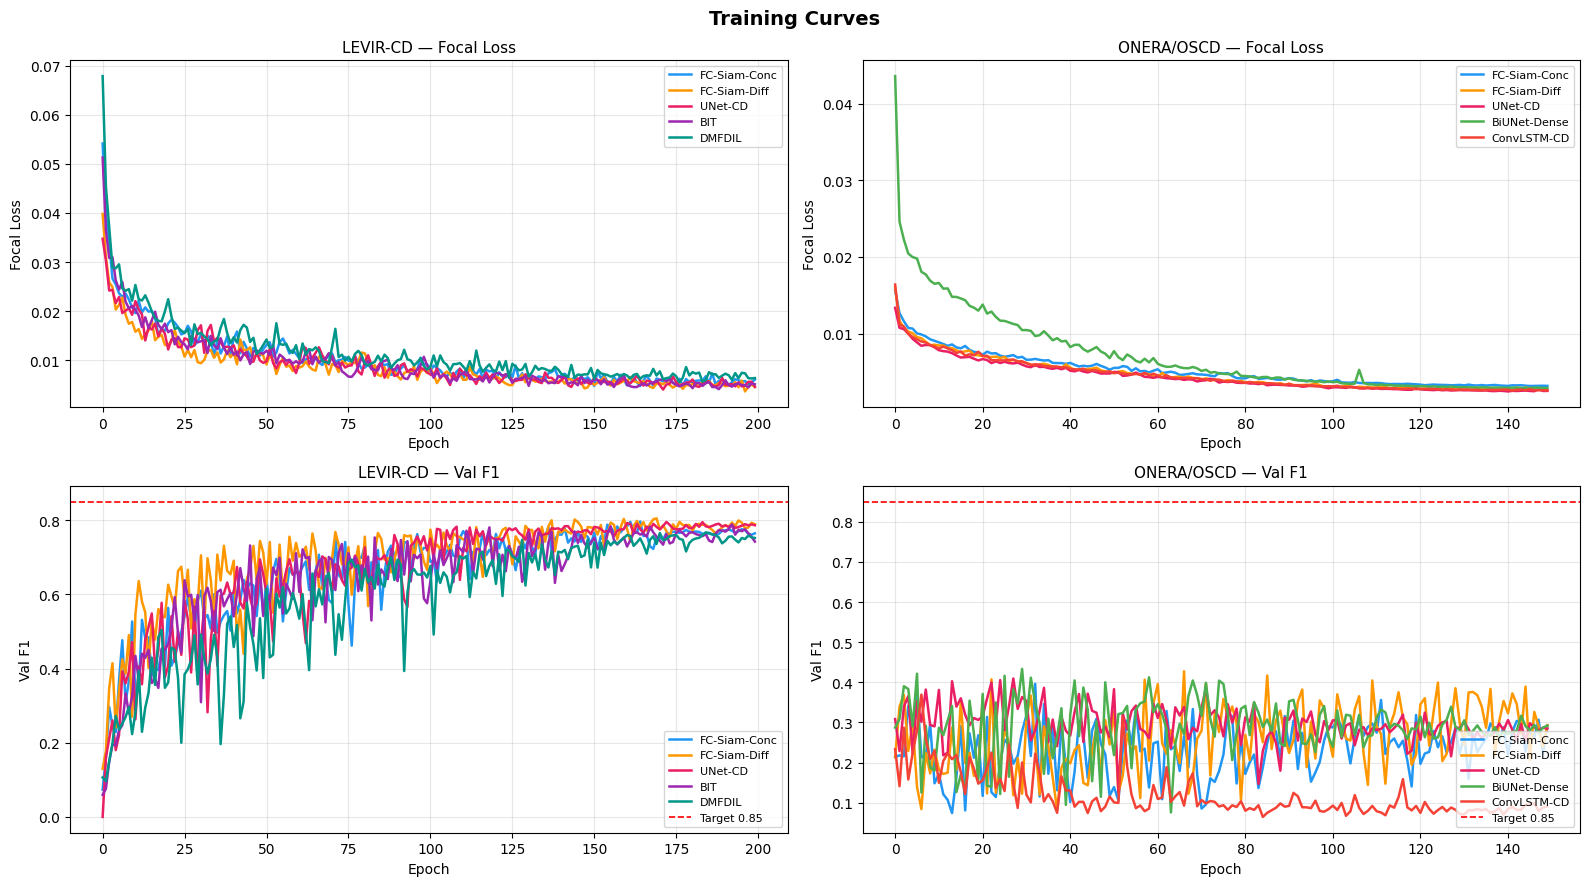

In [44]:
LCOLORS = ['#2196F3','#FF9800','#E91E63','#9C27B0','#009688']
OCOLORS = ['#2196F3','#FF9800','#E91E63','#4CAF50','#F44336']

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Training Curves', fontsize=14, fontweight='bold')

for col, (hist_dict, colors, ds) in enumerate([
        (levir_hist, LCOLORS, 'LEVIR-CD'),
        (onera_hist, OCOLORS, 'ONERA/OSCD')]):
    for row, key in enumerate(['loss','f1']):
        ax = axes[row,col]
        for (tag,h),c in zip(hist_dict.items(), colors):
            ax.plot(h[key], color=c, lw=1.8, label=tag.split('|')[-1])
        if key == 'f1':
            ax.axhline(0.85, color='red', ls='--', lw=1.2, label='Target 0.85')
        ylabel = 'Focal Loss' if key=='loss' else 'Val F1'
        ax.set_title(f'{ds} — {ylabel}', fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8, loc='lower right' if key=='f1' else 'upper right')
        ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'training_curves.png', dpi=130)
plt.show()


## 13 · Model Comparison : Bar Charts


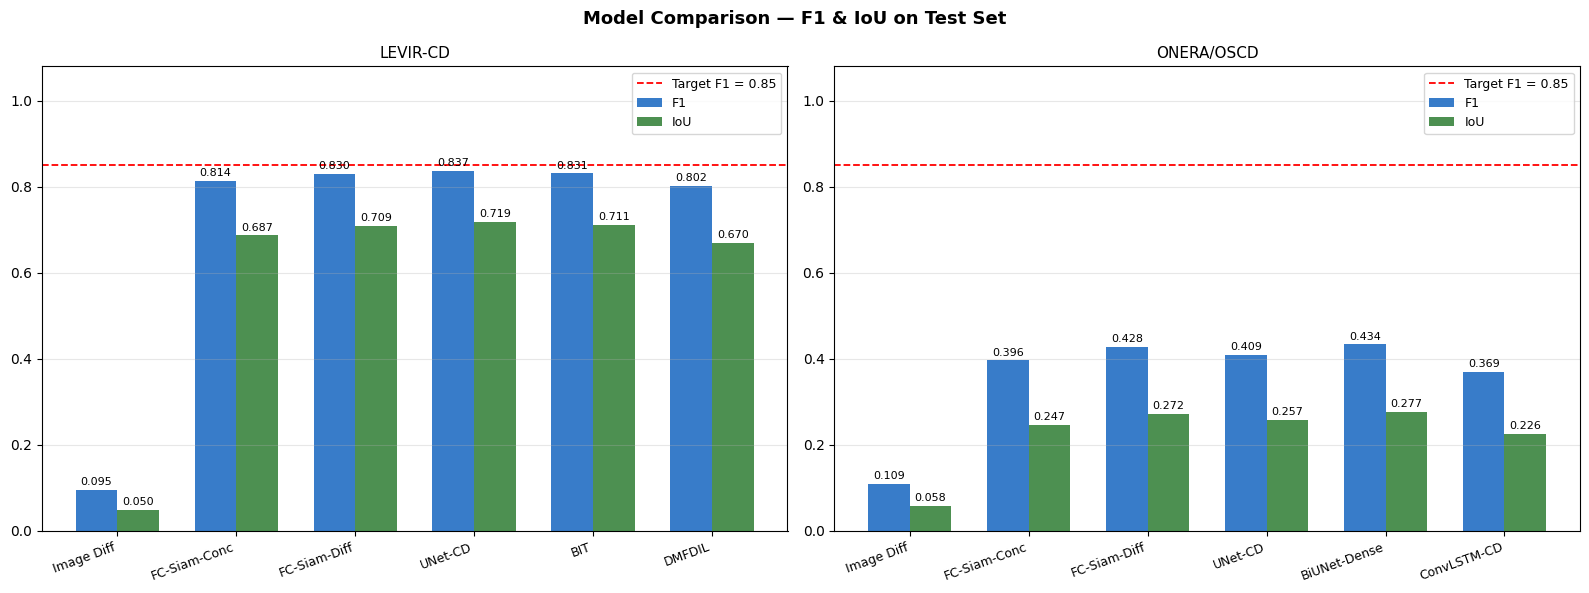

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — F1 & IoU on Test Set', fontsize=13, fontweight='bold')

for ax, prefix, title, colors in [
        (axes[0], 'LEVIR',  'LEVIR-CD',   LCOLORS),
        (axes[1], 'ONERA',  'ONERA/OSCD', OCOLORS)]:
    sub   = {k:v for k,v in all_results.items() if prefix in k}
    names = [k.split('|')[-1] if '|' in k else k for k in sub]
    f1s   = [v['f1']  for v in sub.values()]
    ious  = [v['iou'] for v in sub.values()]
    x = np.arange(len(names)); w = 0.35
    b1 = ax.bar(x-w/2, f1s,  w, label='F1',  color='#1565C0', alpha=.85)
    b2 = ax.bar(x+w/2, ious, w, label='IoU', color='#2E7D32', alpha=.85)
    ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=2)
    ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=2)
    ax.axhline(0.85, color='red', ls='--', lw=1.3, label='Target F1 = 0.85')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.08); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'model_comparison.png', dpi=130)
plt.show()


## 14 · Change Map Visualisation

For each dataset we show a sample with:
- **T1** and **T2** images (RGB / false-colour for ONERA)
- **Ground truth** change mask
- **Image differencing** baseline output
- **Probability map** and **binary prediction** for every deep model


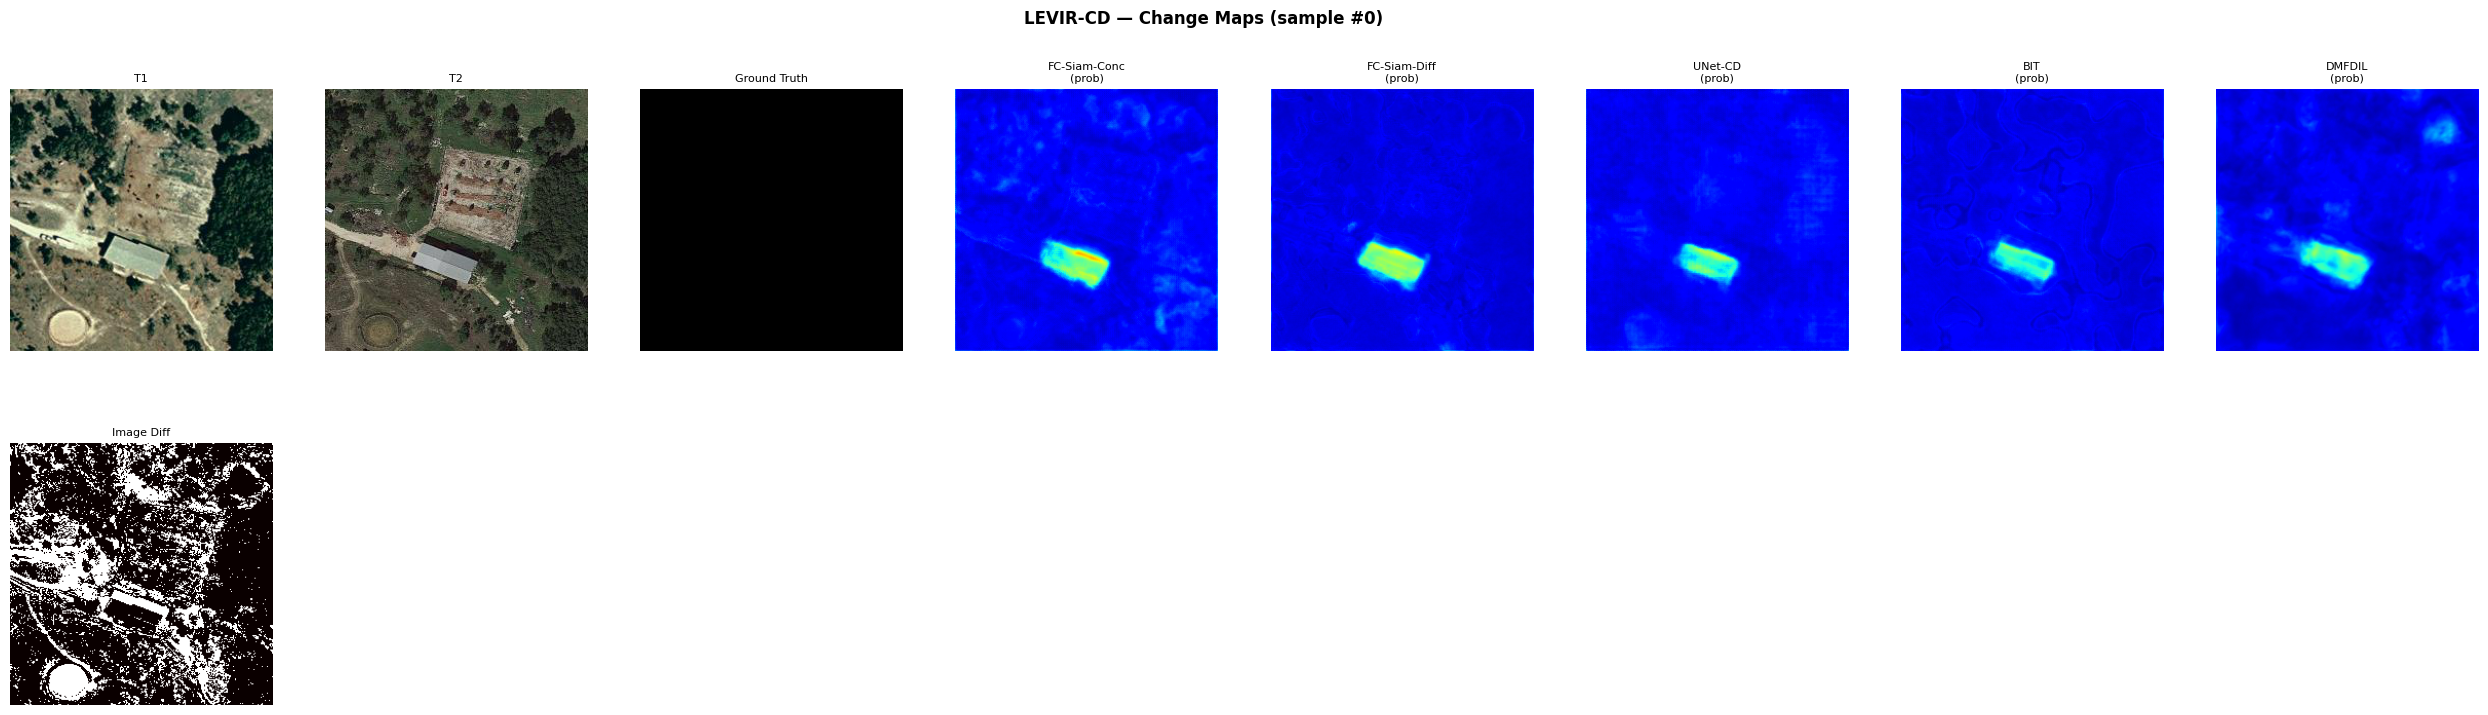

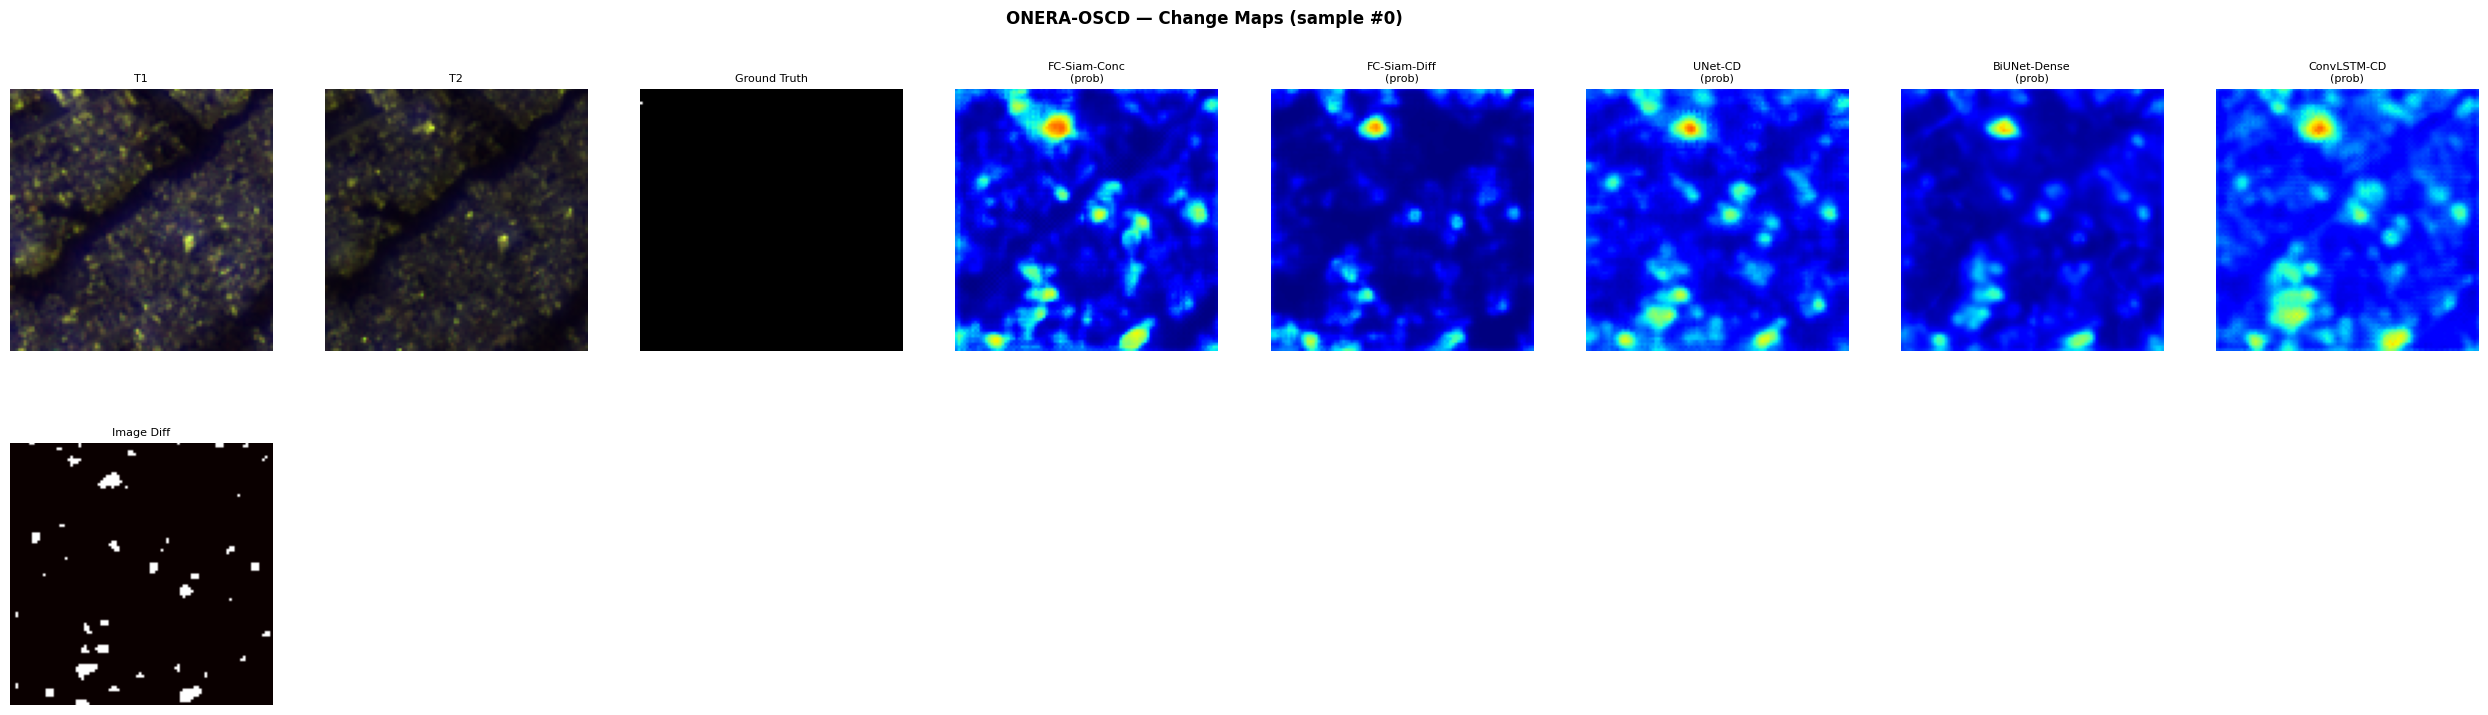

In [46]:
@torch.no_grad()
def predict_one(mdl, i1, i2, dev, thr=0.5):
    mdl.eval()
    out = mdl(i1.unsqueeze(0).to(dev), i2.unsqueeze(0).to(dev))
    if isinstance(out, tuple): out = out[0]
    prob = torch.sigmoid(out.squeeze()).cpu().numpy()
    return (prob > thr).astype(np.uint8), prob

def to_rgb(tensor, is_levir):
    MEAN = np.array(LEVIR_MEAN, np.float32)
    STD  = np.array(LEVIR_STD,  np.float32)
    if is_levir:
        img = tensor.permute(1,2,0).numpy() * STD + MEAN
    else:
        img = tensor[[2,1,0]].permute(1,2,0).numpy()   # B04/B03/B02
        img = (img - img.min()) / (img.max()-img.min()+1e-6)
    return np.clip(img, 0, 1)

def diff_baseline(i1, i2, is_levir):
    MEAN = np.array(LEVIR_MEAN, np.float32)
    STD  = np.array(LEVIR_STD,  np.float32)
    if is_levir:
        a = i1.permute(1,2,0).numpy()*STD+MEAN
        b = i2.permute(1,2,0).numpy()*STD+MEAN
        return otsu(np.abs(b-a).mean(-1).astype(np.float32))
    else:
        dv = (i2-i1).permute(1,2,0).numpy()
        H,W,C = dv.shape
        sc = np.abs(PCA(1).fit_transform(dv.reshape(-1,C))).reshape(H,W)
        return otsu(sc.astype(np.float32))


def show_change_maps(ds_name, mdl_dict, dataset, dev, idx=0, is_levir=True):
    i1,i2,mask = dataset[idx]
    label = mask.numpy().astype(int)
    models = list(mdl_dict.items())
    n = len(models)

    fig = plt.figure(figsize=(4*(n+3), 8))
    fig.suptitle(f'{ds_name} — Change Maps (sample #{idx})',
                 fontsize=12, fontweight='bold')
    gs = fig.add_gridspec(2, n+3, hspace=0.35, wspace=0.15)

    def _show(ax, img, title, **kw):
        ax.imshow(img, **kw); ax.set_title(title, fontsize=8); ax.axis('off')

    _show(fig.add_subplot(gs[0,0]), to_rgb(i1,is_levir), 'T1')
    _show(fig.add_subplot(gs[0,1]), to_rgb(i2,is_levir), 'T2')
    _show(fig.add_subplot(gs[0,2]), label, 'Ground Truth', cmap='gray', vmin=0, vmax=1)
    _show(fig.add_subplot(gs[1,0]), diff_baseline(i1,i2,is_levir),
          'Image Diff', cmap='hot', vmin=0, vmax=1)

    positions = [(0,3),(0,4),(0,5),(0,6),(0,7),
                 (1,1),(1,2),(1,3),(1,4),(1,5)]
    for (r,c),(tag,mdl) in zip(positions, models):
        pred, prob = predict_one(mdl, i1, i2, dev)
        short = tag.split('|')[-1]
        try:
            ax = fig.add_subplot(gs[r,c])
            _show(ax, prob, f'{short}\n(prob)', cmap='jet', vmin=0, vmax=1)
        except Exception:
            pass

    plt.savefig(OUT_DIR/f'{ds_name.replace("/","_")}_maps.png',
                dpi=130, bbox_inches='tight')
    plt.show()


show_change_maps('LEVIR-CD',   levir_models, lev_te, DEVICE, idx=0, is_levir=True)
show_change_maps('ONERA-OSCD', onera_models, on_va,  DEVICE, idx=0, is_levir=False)


## 15 · Error Analysis : False Positives & False Negatives

### Colour code
| Colour | Meaning | Description |
|---|---|---|
| ⬜ White | **True Positive (TP)** | Correctly detected change |
| 🟥 Red | **False Positive (FP)** | Change predicted but not present — false alarm |
| 🟦 Blue | **False Negative (FN)** | Change present but missed — missed detection |
| ⬛ Black | **True Negative (TN)** | Correctly detected no-change |

### What to look for
- **Image Differencing** → large red regions around roads, water, vegetation (illumination noise)
- **Siamese Diff models** → fewer FP in stable areas than Siamese Conc
- **BIT / DMFDIL** (LEVIR) → fewer FN in partially changed buildings (global context helps)
- **ConvLSTM-CD** (ONERA) → fewer FP from seasonal vegetation change (temporal gating)


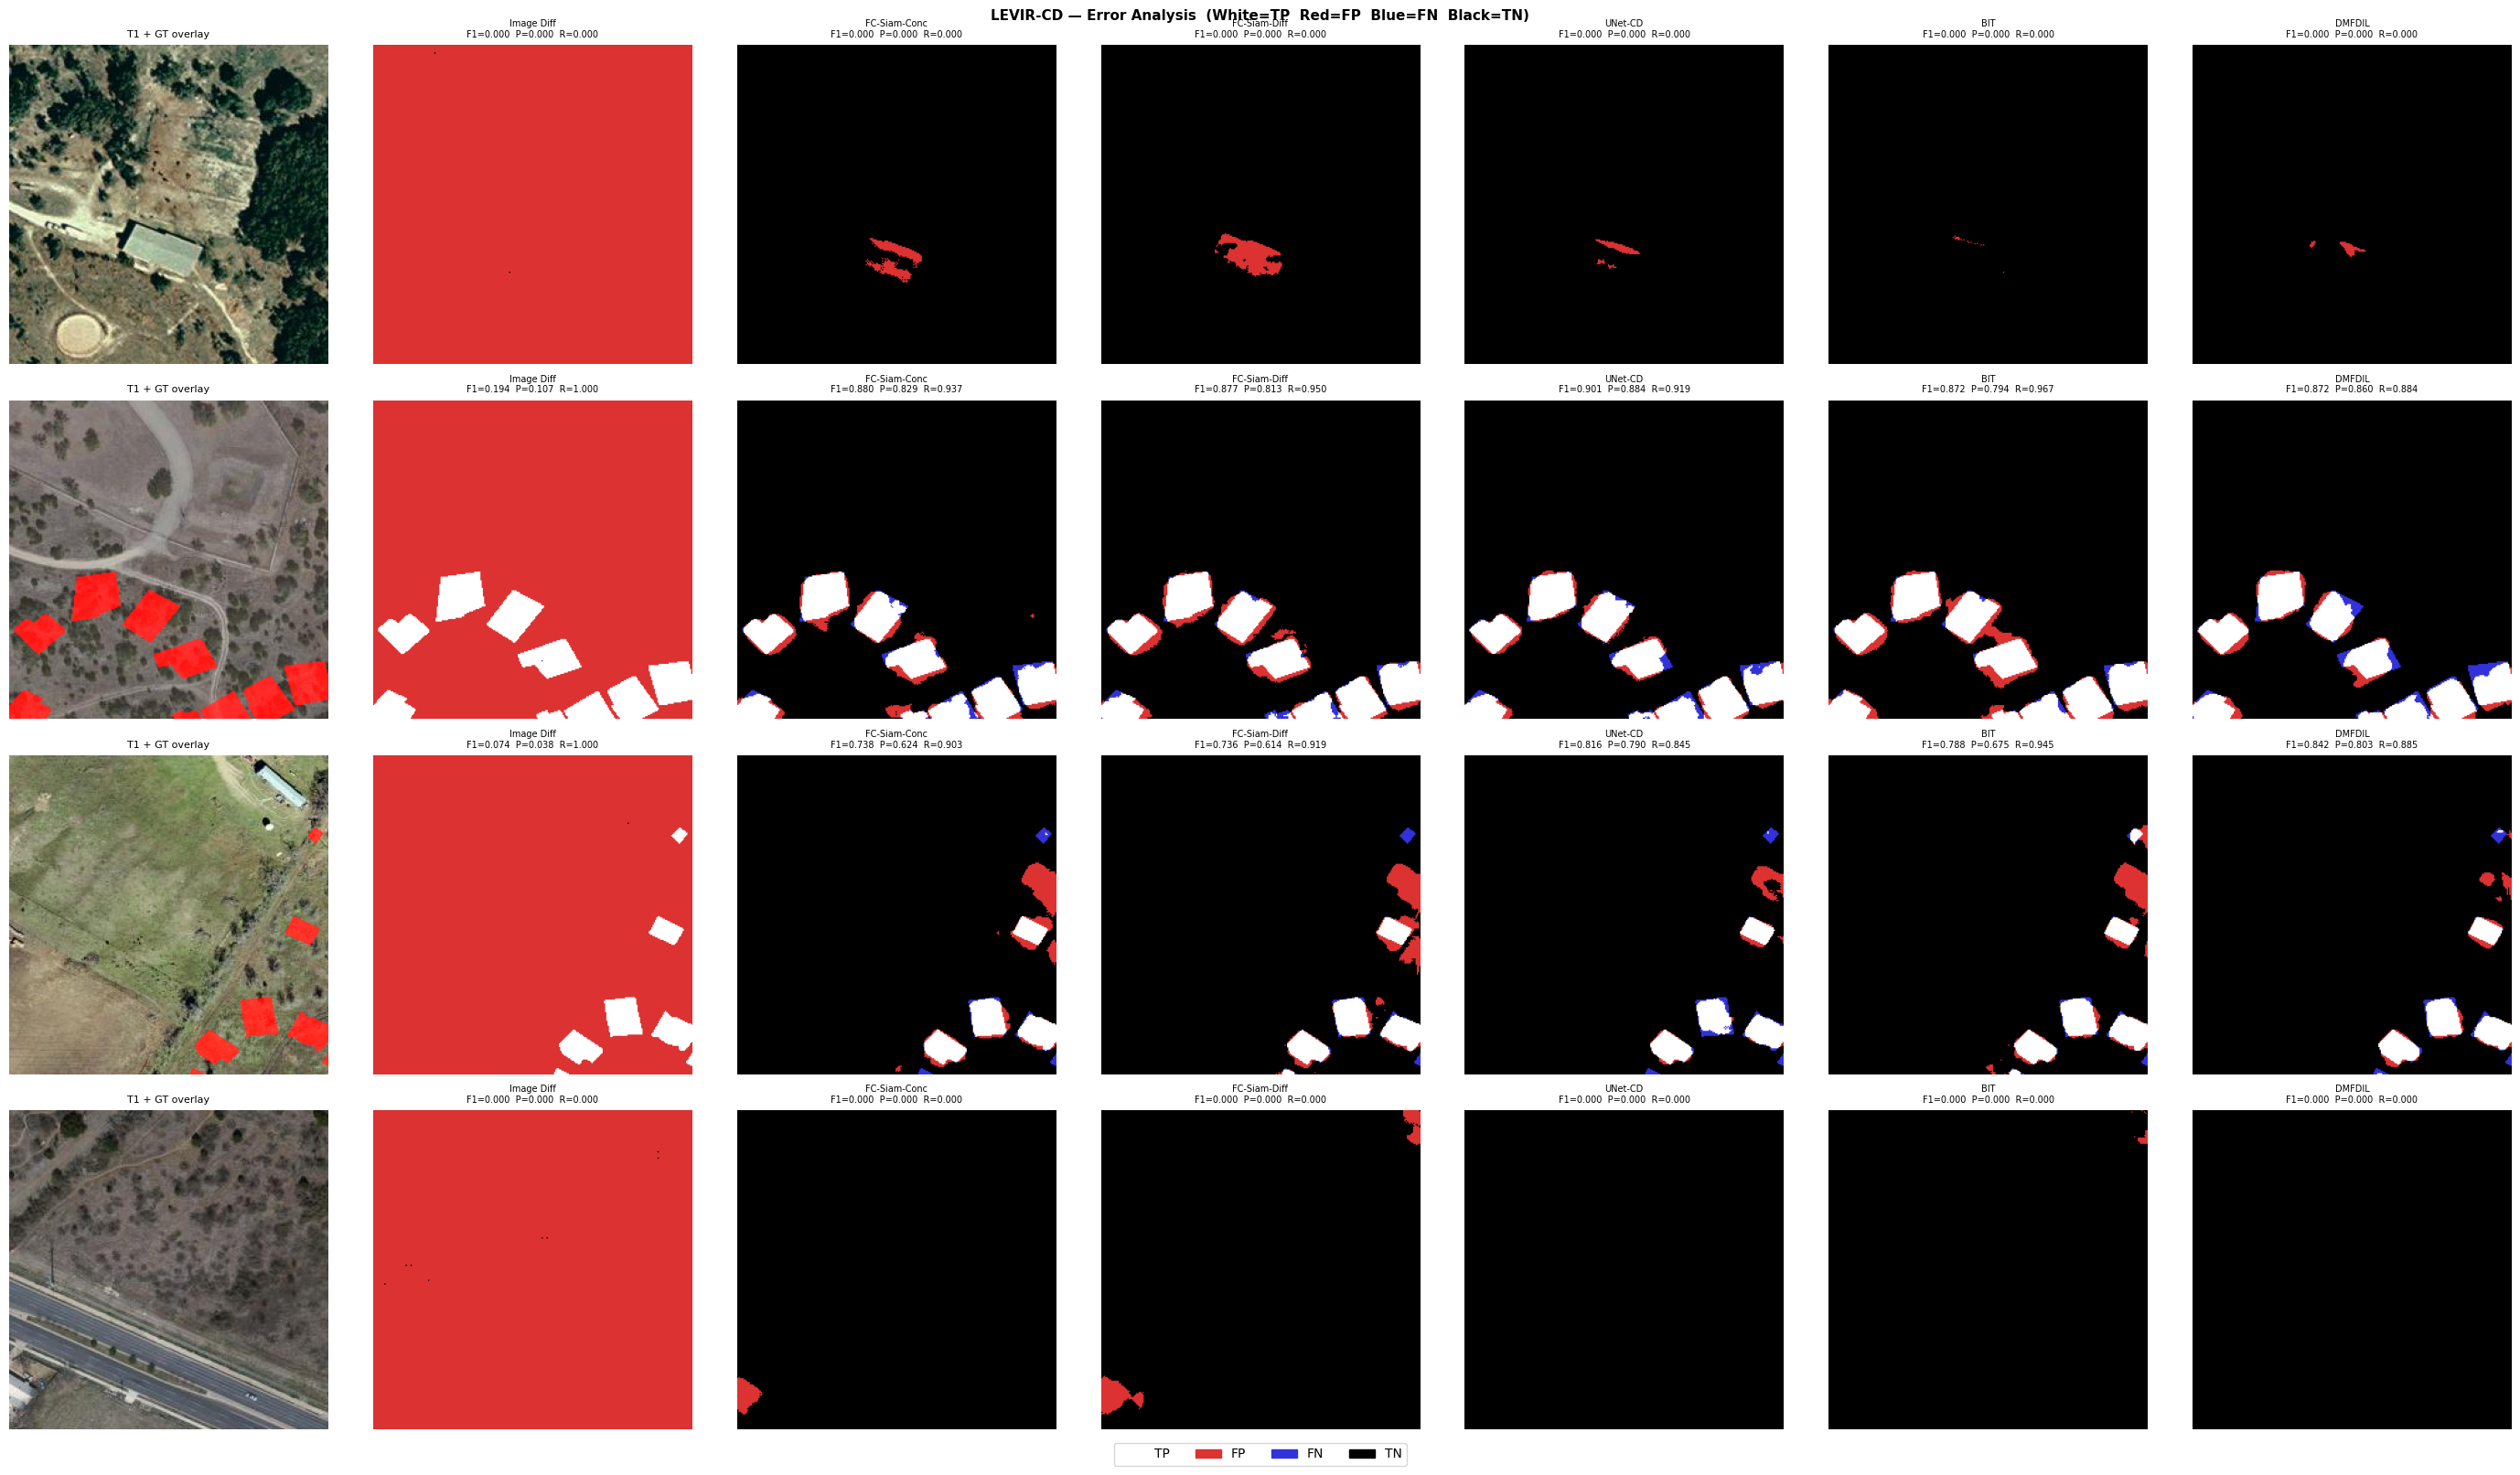

Saved \content\outputs\LEVIR-CD_errors.png


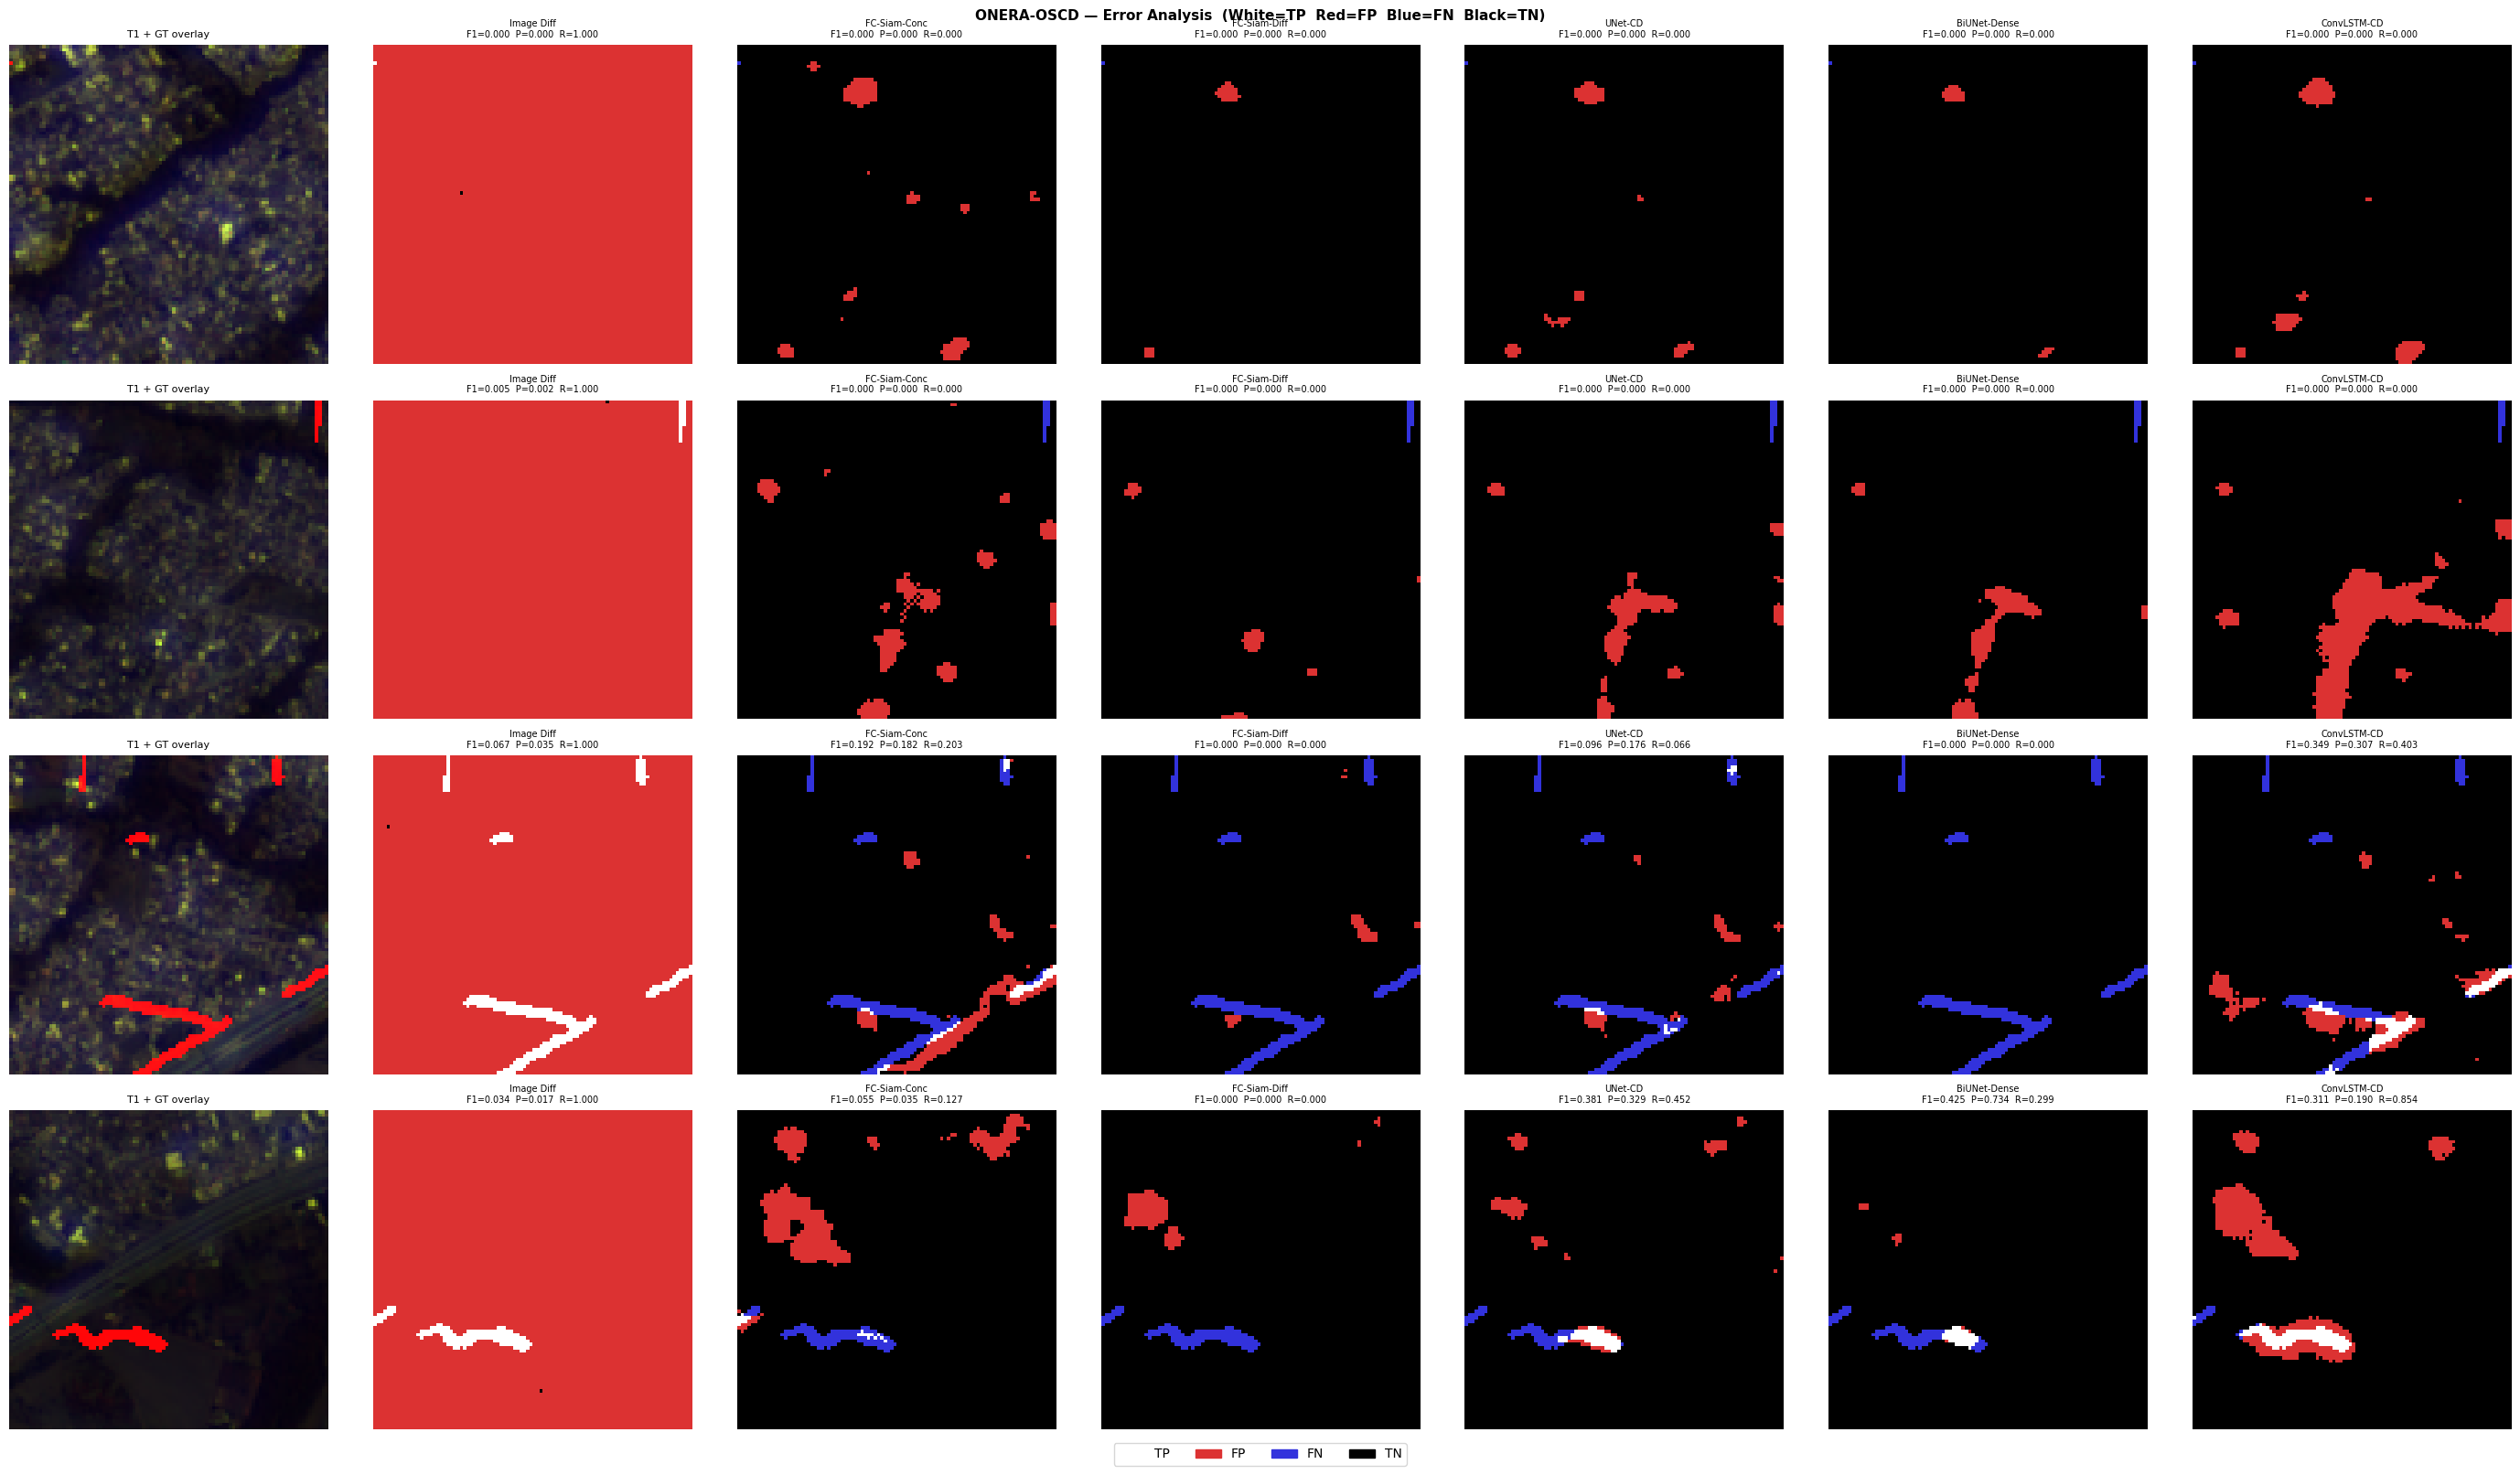

Saved \content\outputs\ONERA-OSCD_errors.png


In [47]:
def error_map(pred, label):
    rgb = np.zeros((*pred.shape,3), np.uint8)
    rgb[(pred==1)&(label==1)] = [255,255,255]   # TP white
    rgb[(pred==1)&(label==0)] = [220, 50, 50]   # FP red
    rgb[(pred==0)&(label==1)] = [ 50, 50,220]   # FN blue
    # TN stays black
    return rgb


def plot_error_analysis(ds_name, mdl_dict, dataset, dev, n=4, is_levir=True):
    n = min(n, len(dataset))
    models = list(mdl_dict.items())
    nm = len(models)

    MEAN = np.array(LEVIR_MEAN, np.float32)
    STD  = np.array(LEVIR_STD,  np.float32)

    fig, axes = plt.subplots(n, nm+1, figsize=(4*(nm+1), 4*n))
    if n == 1: axes = axes[np.newaxis]
    fig.suptitle(
        f'{ds_name} — Error Analysis  '
        f'(White=TP  Red=FP  Blue=FN  Black=TN)',
        fontsize=11, fontweight='bold')

    for row in range(n):
        i1,i2,mask = dataset[row]
        label = mask.numpy().astype(int)

        # T1 with GT overlay
        vis = to_rgb(i1, is_levir)
        ov  = (vis*255).astype(np.uint8)
        ov[label==1,0] = 255
        ov[label==1,1] = (ov[label==1,1]*.4).astype(np.uint8)
        ov[label==1,2] = (ov[label==1,2]*.4).astype(np.uint8)
        axes[row,0].imshow(ov)
        axes[row,0].set_title('T1 + GT overlay', fontsize=8)
        axes[row,0].axis('off')

        for col,(tag,mdl) in enumerate(models, 1):
            pred,_ = predict_one(mdl, i1, i2, dev)
            em = error_map(pred, label)
            m  = compute_metrics(pred.ravel(), label.ravel())
            axes[row,col].imshow(em)
            axes[row,col].set_title(
                f'{tag.split("|")[-1]}\n'
                f'F1={m["f1"]:.3f}  P={m["precision"]:.3f}  R={m["recall"]:.3f}',
                fontsize=7)
            axes[row,col].axis('off')

    # Legend
    patches = [
        mpatches.Patch(color='white',       label='TP', linewidth=1,
                       edgecolor='gray'),
        mpatches.Patch(color=(220/255,50/255,50/255), label='FP'),
        mpatches.Patch(color=(50/255,50/255,220/255), label='FN'),
        mpatches.Patch(color='black',       label='TN'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=4,
               fontsize=10, frameon=True, bbox_to_anchor=(0.5,-0.02))

    plt.tight_layout()
    fn = OUT_DIR/f'{ds_name.replace("/","_")}_errors.png'
    plt.savefig(fn, dpi=130, bbox_inches='tight')
    plt.show(); print(f'Saved {fn}')


# Include image diff in error analysis by wrapping it as a pseudo-model
class ImgDiffModel(nn.Module):
    """Thin wrapper so image differencing plugs into the same error analysis."""

    def __init__(self, is_levir):
        super().__init__()
        self.is_levir = is_levir
        self.dummy = nn.Parameter(torch.zeros(1))   # keeps nn.Module happy

    def forward(self, i1, i2):
        MEAN = np.array(LEVIR_MEAN, np.float32)
        STD  = np.array(LEVIR_STD,  np.float32)
        out = []
        for b in range(i1.shape[0]):
            if self.is_levir:
                a = i1[b].cpu().permute(1,2,0).numpy()*STD+MEAN
                c = i2[b].cpu().permute(1,2,0).numpy()*STD+MEAN
                diff = np.abs(c-a).mean(-1).astype(np.float32)
            else:
                dv = (i2[b]-i1[b]).cpu().permute(1,2,0).numpy()
                H,W,C = dv.shape
                diff = np.abs(
                    PCA(1).fit_transform(dv.reshape(-1,C))
                ).reshape(H,W).astype(np.float32)
            # Otsu, return as float logit-like in [0,1]
            norm = cv2.normalize(diff,None,0,1,cv2.NORM_MINMAX)
            out.append(torch.from_numpy(norm))
        return torch.stack(out).unsqueeze(1)


lev_all = {'LEVIR|Image Diff': ImgDiffModel(True)}
lev_all.update(levir_models)

on_all = {'ONERA|Image Diff': ImgDiffModel(False)}
on_all.update(onera_models)

plot_error_analysis('LEVIR-CD',   lev_all, lev_te, DEVICE, n=4, is_levir=True)
plot_error_analysis('ONERA-OSCD', on_all,  on_va,  DEVICE, n=4, is_levir=False)


## 16 · False Positive / False Negative Breakdown

Quantitative FP and FN analysis across all models.
Since FP and FN represent different operational costs
(false alarms vs. missed detections), plotting them separately
reveals each model's trade-off profile.


Computing FP/FN rates …


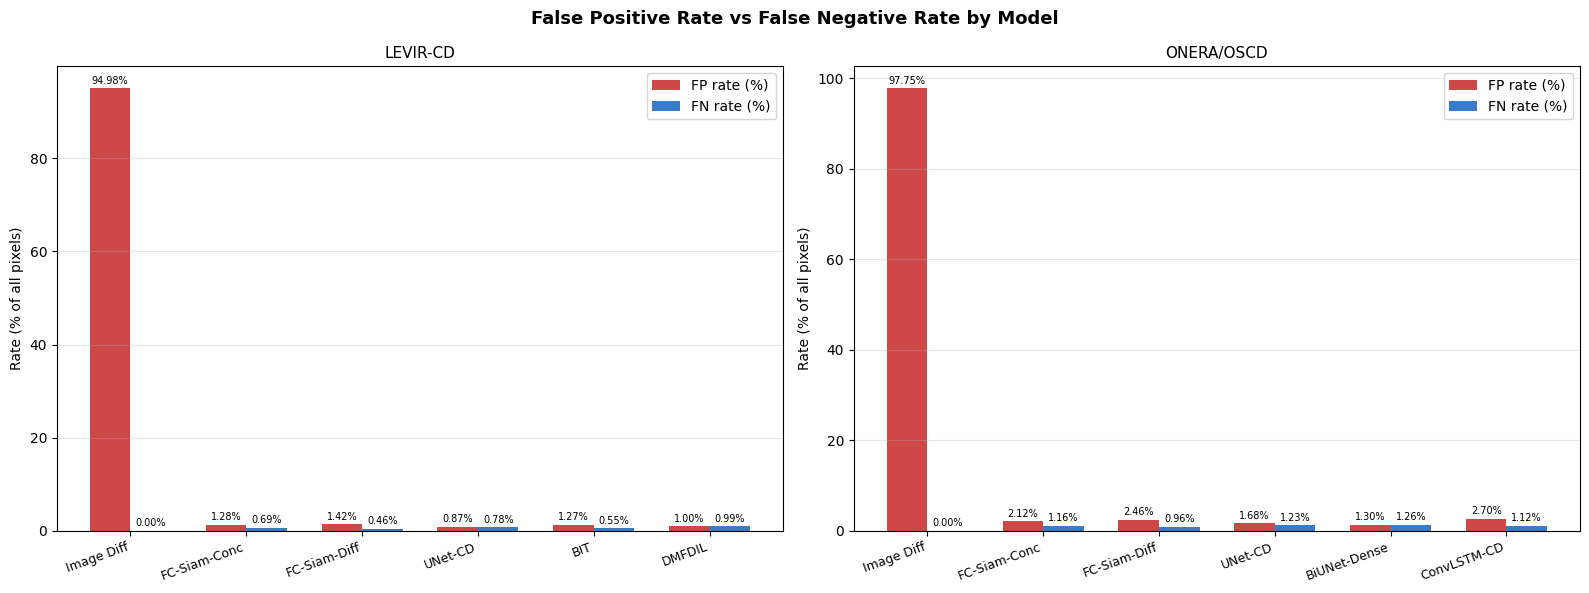

In [48]:
@torch.no_grad()
def fp_fn_rates(model, loader, dev, n=200):
    """Returns mean FP rate and FN rate over n samples."""

    tp_total = fp_total = fn_total = tn_total = 0
    count = 0
    for i1, i2, m in loader:
        out = model(i1.to(dev), i2.to(dev))
        if isinstance(out, tuple): out = out[0]
        pred  = (torch.sigmoid(out.squeeze(1)) > CFG['threshold']
                 ).cpu().numpy().astype(int)
        label = m.numpy().astype(int)
        for b in range(pred.shape[0]):
            if count >= n: break
            p = pred[b].ravel(); l = label[b].ravel()
            tp_total += ((p==1)&(l==1)).sum()
            fp_total += ((p==1)&(l==0)).sum()
            fn_total += ((p==0)&(l==1)).sum()
            tn_total += ((p==0)&(l==0)).sum()
            count += 1
        if count >= n: break
    total = tp_total + fp_total + fn_total + tn_total + 1e-9
    return fp_total/total, fn_total/total


print('Computing FP/FN rates …')
fp_fn = {}
for tag, mdl in {**lev_all, **on_all}.items():
    loader = lev_te_loader if 'LEVIR' in tag else on_va_loader
    fp, fn = fp_fn_rates(mdl, loader, DEVICE)
    fp_fn[tag] = (fp, fn)

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('False Positive Rate vs False Negative Rate by Model',
             fontsize=13, fontweight='bold')

for ax, prefix, title in [
        (axes[0], 'LEVIR', 'LEVIR-CD'),
        (axes[1], 'ONERA', 'ONERA/OSCD')]:
    sub = {k:v for k,v in fp_fn.items() if prefix in k}
    names  = [k.split('|')[-1] if '|' in k else k for k in sub]
    fp_r   = [v[0]*100 for v in sub.values()]
    fn_r   = [v[1]*100 for v in sub.values()]
    x = np.arange(len(names)); w = 0.35
    b1 = ax.bar(x-w/2, fp_r, w, label='FP rate (%)', color='#C62828', alpha=.85)
    b2 = ax.bar(x+w/2, fn_r, w, label='FN rate (%)', color='#1565C0', alpha=.85)
    ax.bar_label(b1, fmt='%.2f%%', fontsize=7, padding=2)
    ax.bar_label(b2, fmt='%.2f%%', fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Rate (% of all pixels)')
    ax.set_title(title, fontsize=11); ax.legend(); ax.grid(axis='y', alpha=.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'fp_fn_analysis.png', dpi=130)
plt.show()


## 17 · Summary & Conclusions


In [49]:
print('  FINAL RANKED RESULTS')

for prefix, ds in [('LEVIR','LEVIR-CD'),('ONERA','ONERA/OSCD')]:
    print(f'\n  {ds}')
    sub = sorted(
        {k:v for k,v in all_results.items() if prefix in k}.items(),
        key=lambda x: x[1]['f1'], reverse=True)
    for i,(name,m) in enumerate(sub,1):
        short = name.split('|')[-1] if '|' in name else name
        ok = '✓ TARGET' if m['f1']>=0.85 else ''
        print(f'  {i}. {short:<22} '
              f'F1={m["f1"]:.4f}  IoU={m["iou"]:.4f}  '
              f'Kappa={m["kappa"]:.4f}  {ok}')



  FINAL RANKED RESULTS

  LEVIR-CD
  1. UNet-CD                F1=0.8367  IoU=0.7192  Kappa=0.8280  
  2. BIT                    F1=0.8312  IoU=0.7112  Kappa=0.8217  
  3. FC-Siam-Diff           F1=0.8296  IoU=0.7089  Kappa=0.8198  
  4. FC-Siam-Conc           F1=0.8144  IoU=0.6869  Kappa=0.8040  
  5. DMFDIL                 F1=0.8021  IoU=0.6696  Kappa=0.7916  
  6.  Image Diff            F1=0.0949  IoU=0.0498  Kappa=0.0080  

  ONERA/OSCD
  1. BiUNet-Dense           F1=0.4336  IoU=0.2768  Kappa=0.4205  
  2. FC-Siam-Diff           F1=0.4276  IoU=0.2719  Kappa=0.4111  
  3. UNet-CD                F1=0.4095  IoU=0.2575  Kappa=0.3947  
  4. FC-Siam-Conc           F1=0.3963  IoU=0.2472  Kappa=0.3800  
  5. ConvLSTM-CD            F1=0.3693  IoU=0.2265  Kappa=0.3510  
  6.  Image Diff            F1=0.1090  IoU=0.0576  Kappa=0.0720  
